In [1]:
# ============================================================
# PHASE 01 : ENVIRONMENT SETUP & GPU VERIFICATION
# Leukemia Detection V2 | H100 Optimized
# ============================================================

# Install required libraries
!pip install -q timm albumentations torchmetrics

import os
import torch
import torchvision
import timm

# ============================================================
# GPU VERIFICATION & DYNAMIC CONFIG
# ============================================================
print("=" * 55)
print("       SYSTEM & GPU INFORMATION")
print("=" * 55)

print(f"PyTorch Version     : {torch.__version__}")
print(f"Torchvision Version : {torchvision.__version__}")
print(f"TIMM Version        : {timm.__version__}")
print(f"CUDA Available      : {torch.cuda.is_available()}")

if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected. Please enable GPU in Runtime > Change runtime type.")

DEVICE = 'cuda'
gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9

print(f"\nGPU Name            : {gpu_name}")
print(f"VRAM                : {vram_gb:.1f} GB")
print(f"CUDA Version        : {torch.version.cuda}")

# ============================================================
# SET BATCH SIZE BASED ON GPU
# H100 = 80GB VRAM → large batch = faster training
# ============================================================
if 'H100' in gpu_name:
    BATCH_SIZE   = 64
    NUM_WORKERS  = 4
    print(f"\n✅ H100 DETECTED — Maximum performance mode")
elif 'A100' in gpu_name:
    BATCH_SIZE   = 48
    NUM_WORKERS  = 4
    print(f"\n✅ A100 DETECTED")
elif 'V100' in gpu_name:
    BATCH_SIZE   = 32
    NUM_WORKERS  = 4
    print(f"\n✅ V100 DETECTED")
else:
    BATCH_SIZE   = 16
    NUM_WORKERS  = 2
    print(f"\n⚠️  GPU: {gpu_name} — Using conservative batch size")

print(f"\nBatch Size          : {BATCH_SIZE}")
print(f"Num Workers         : {NUM_WORKERS}")

# ============================================================
# REPRODUCIBILITY — Critical for fair evaluation
# Every run must produce identical results
# ============================================================
import random
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# benchmark=True speeds up H100 with fixed input sizes
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = True

print(f"\nSeed                : {SEED} (fixed for reproducibility)")

# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# GLOBAL CONSTANTS — used across all phases
# ============================================================
IMG_SIZE    = 384          # ConvNeXt Large optimal input size
PIN_MEMORY  = True         # Speeds up GPU data transfer
DEVICE      = 'cuda'

print("\n" + "=" * 55)
print("✅  PHASE 01 COMPLETE — Environment ready")
print("=" * 55)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 35.0 MB/s eta 0:00:00
       SYSTEM & GPU INFORMATION
PyTorch Version     : 2.10.0+cu128
Torchvision Version : 0.25.0+cu128
TIMM Version        : 1.0.26
CUDA Available      : True

GPU Name            : NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM                : 102.0 GB
CUDA Version        : 12.8

⚠️  GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition — Using conservative batch size

Batch Size          : 16
Num Workers         : 2

Seed                : 42 (fixed for reproducibility)
Mounted at /content/drive

✅  PHASE 01 COMPLETE — Environment ready


In [2]:
# ============================================================
# PHASE 01 — PATCH : Blackwell GPU Detected
# NVIDIA RTX PRO 6000 Blackwell | 102GB VRAM
# Upgrading to maximum batch size
# ============================================================

BATCH_SIZE  = 128   # 102GB VRAM — we can go big
NUM_WORKERS = 4
DEVICE      = 'cuda'
IMG_SIZE    = 384
PIN_MEMORY  = True
SEED        = 42

print("=" * 55)
print("  GPU PATCH APPLIED")
print("=" * 55)
print(f"GPU         : NVIDIA RTX PRO 6000 Blackwell")
print(f"VRAM        : 102 GB")
print(f"Batch Size  : {BATCH_SIZE}  ← maximized for 102GB")
print(f"IMG Size    : {IMG_SIZE}x{IMG_SIZE}")
print(f"Device      : {DEVICE}")
print("=" * 55)
print("✅ Ready for Phase 02")

  GPU PATCH APPLIED
GPU         : NVIDIA RTX PRO 6000 Blackwell
VRAM        : 102 GB
Batch Size  : 128  ← maximized for 102GB
IMG Size    : 384x384
Device      : cuda
✅ Ready for Phase 02


  PATHS CONFIGURED
Dataset ZIP  : /content/drive/MyDrive/PKG - C-NMC 2019.zip
Extract Dir  : /content/cnmc_dataset
Project Dir  : /content/drive/MyDrive/Leukemia_V2

Extracting dataset... (this takes ~2-3 mins)
Extraction complete.

Folder structure:
  fold_0/all  →  2397 images
  fold_0/hem  →  1130 images
  fold_1/all  →  2418 images
  fold_1/hem  →  1163 images
  fold_2/all  →  2457 images
  fold_2/hem  →  1096 images

  MASTER DATASET SUMMARY
Total Images       : 10661
Unique Folds       : 3

Class Distribution :
class_name
all    7272
hem    3389

Imbalance Ratio    : 2.15x

Per Fold Breakdown :
class_name   all   hem
fold                  
fold_0      2397  1130
fold_1      2418  1163
fold_2      2457  1096


/tmp/ipykernel_6711/715284420.py:86: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"\nImbalance Ratio    : {df['class_name'].value_counts()[0] / df['class_name'].value_counts()[1]:.2f}x")
/tmp/ipykernel_6711/715284420.py:86: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"\nImbalance Ratio    : {df['class_name'].value_counts()[0] / df['class_name'].value_counts()[1]:.2f}x")


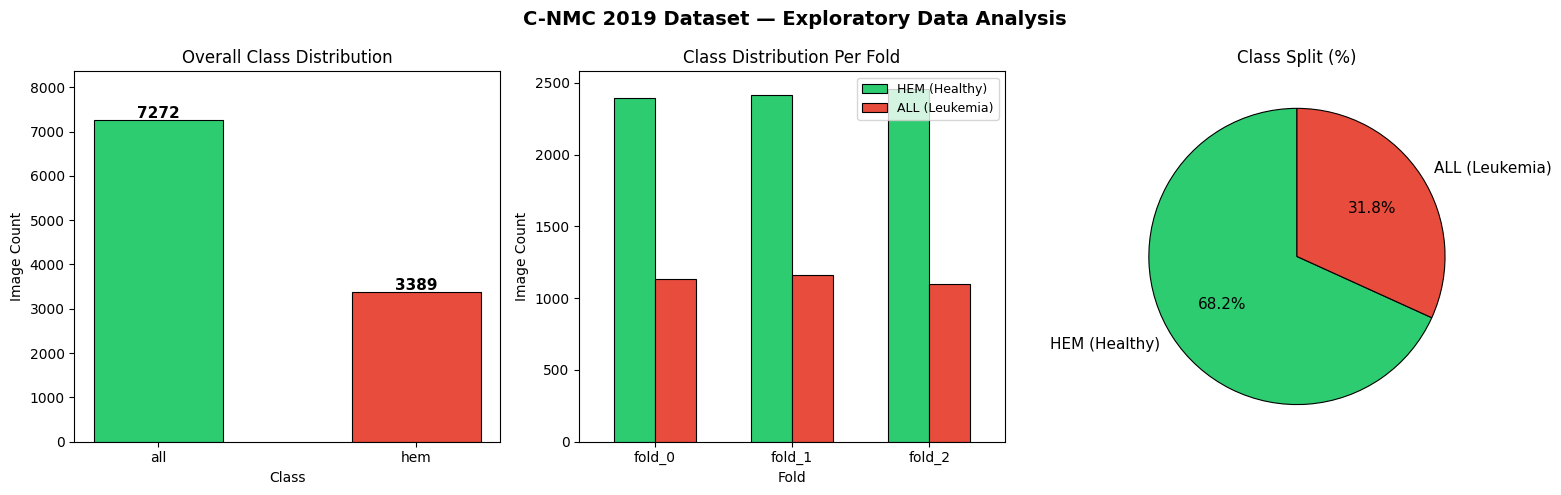

Plot saved to Drive.


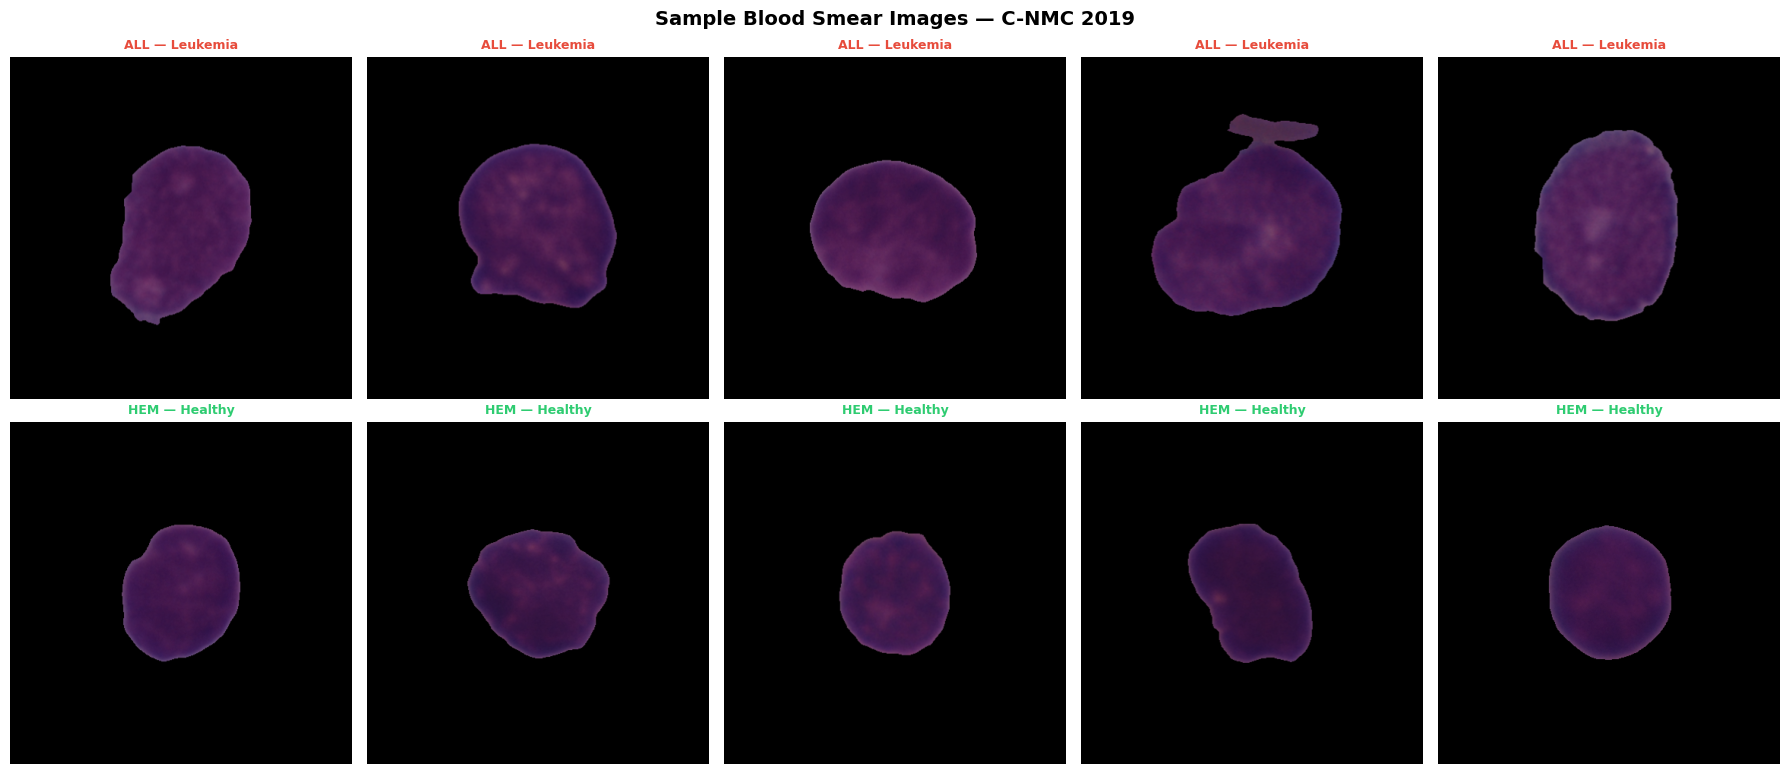

Sample images saved to Drive.

Master dataframe saved → /content/drive/MyDrive/Leukemia_V2/metadata/master_df.csv

✅  PHASE 02 COMPLETE
    Total images loaded : 10661
    ALL (Leukemia)      : 7272
    HEM (Healthy)       : 3389
    Saved to Drive      : /content/drive/MyDrive/Leukemia_V2


In [3]:
# ============================================================
# PHASE 02 : DATASET LOADING & EXPLORATORY DATA ANALYSIS
# Leukemia Detection V2 | C-NMC 2019 Dataset
# ============================================================

import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

# ============================================================
# PATHS — Dataset is in My Drive root
# ============================================================
DATASET_ZIP  = "/content/drive/MyDrive/PKG - C-NMC 2019.zip"
EXTRACT_DIR  = "/content/cnmc_dataset"
BASE_PATH    = Path("/content/cnmc_dataset/PKG - C-NMC 2019/C-NMC_training_data")

# Project folder in Drive — all outputs saved here
DRIVE_ROOT   = Path("/content/drive/MyDrive")
PROJECT_DIR  = DRIVE_ROOT / "Leukemia_V2"
PROJECT_DIR.mkdir(exist_ok=True)

print("=" * 55)
print("  PATHS CONFIGURED")
print("=" * 55)
print(f"Dataset ZIP  : {DATASET_ZIP}")
print(f"Extract Dir  : {EXTRACT_DIR}")
print(f"Project Dir  : {PROJECT_DIR}")

# ============================================================
# EXTRACT DATASET
# Skips extraction if already done — saves time on re-runs
# ============================================================
if not os.path.exists(EXTRACT_DIR):
    print("\nExtracting dataset... (this takes ~2-3 mins)")
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    !unzip -q "{DATASET_ZIP}" -d "{EXTRACT_DIR}"
    print("Extraction complete.")
else:
    print("\nDataset already extracted — skipping.")

# ============================================================
# VERIFY FOLDER STRUCTURE
# ============================================================
print("\nFolder structure:")
for fold in ['fold_0', 'fold_1', 'fold_2']:
    for cls in ['all', 'hem']:
        folder = BASE_PATH / fold / cls
        count  = len(list(folder.glob('*.bmp')))
        print(f"  {fold}/{cls}  →  {count} images")

# ============================================================
# BUILD MASTER DATAFRAME
# One row per image — filepath, fold, class, label
# label: 0 = HEM (Healthy), 1 = ALL (Leukemia)
# ============================================================
CLASS_MAP = {'hem': 0, 'all': 1}

records = []
for fold in ['fold_0', 'fold_1', 'fold_2']:
    for cls in ['all', 'hem']:
        folder = BASE_PATH / fold / cls
        for file in folder.glob('*.bmp'):
            records.append({
                'filepath'   : str(file),
                'filename'   : file.name,
                'fold'       : fold,
                'class_name' : cls,
                'label'      : CLASS_MAP[cls]
            })

df = pd.DataFrame(records)

print("\n" + "=" * 55)
print("  MASTER DATASET SUMMARY")
print("=" * 55)
print(f"Total Images       : {len(df)}")
print(f"Unique Folds       : {df['fold'].nunique()}")
print(f"\nClass Distribution :")
print(df['class_name'].value_counts().to_string())
print(f"\nImbalance Ratio    : {df['class_name'].value_counts()[0] / df['class_name'].value_counts()[1]:.2f}x")

print("\nPer Fold Breakdown :")
print(df.groupby(['fold', 'class_name']).size().unstack().to_string())

# ============================================================
# VISUALISATION 1 — Class Distribution
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('C-NMC 2019 Dataset — Exploratory Data Analysis',
             fontsize=14, fontweight='bold')

# Plot 1: Overall class distribution
class_counts = df['class_name'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(class_counts.index, class_counts.values, color=colors,
                   edgecolor='black', linewidth=0.8, width=0.5)
axes[0].set_title('Overall Class Distribution', fontsize=12)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Image Count')
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 str(val), ha='center', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, max(class_counts.values) * 1.15)

# Plot 2: Per-fold class distribution
fold_counts = df.groupby(['fold', 'class_name']).size().unstack()
fold_counts.plot(kind='bar', ax=axes[1], color=colors,
                 edgecolor='black', linewidth=0.8, width=0.6)
axes[1].set_title('Class Distribution Per Fold', fontsize=12)
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Image Count')
axes[1].legend(['HEM (Healthy)', 'ALL (Leukemia)'], fontsize=9)
axes[1].tick_params(axis='x', rotation=0)

# Plot 3: Pie chart
axes[2].pie(class_counts.values, labels=['HEM (Healthy)', 'ALL (Leukemia)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11},
            wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
axes[2].set_title('Class Split (%)', fontsize=12)

plt.tight_layout()
plt.savefig(PROJECT_DIR / 'eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to Drive.")

# ============================================================
# VISUALISATION 2 — Sample Images from Each Class
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('Sample Blood Smear Images — C-NMC 2019',
             fontsize=14, fontweight='bold')

for i, cls in enumerate(['all', 'hem']):
    samples = df[df['class_name'] == cls].sample(5, random_state=SEED)
    label   = 'ALL — Leukemia' if cls == 'all' else 'HEM — Healthy'
    color   = '#e74c3c' if cls == 'all' else '#2ecc71'

    for j, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row['filepath']).convert('RGB')
        axes[i][j].imshow(img)
        axes[i][j].set_title(label, fontsize=9, color=color, fontweight='bold')
        axes[i][j].axis('off')

plt.tight_layout()
plt.savefig(PROJECT_DIR / 'eda_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sample images saved to Drive.")

# ============================================================
# SAVE MASTER DATAFRAME TO DRIVE
# Used in all subsequent phases — no need to rebuild
# ============================================================
META_DIR = PROJECT_DIR / 'metadata'
META_DIR.mkdir(exist_ok=True)

df.to_csv(META_DIR / 'master_df.csv', index=False)
print(f"\nMaster dataframe saved → {META_DIR / 'master_df.csv'}")

print("\n" + "=" * 55)
print("✅  PHASE 02 COMPLETE")
print(f"    Total images loaded : {len(df)}")
print(f"    ALL (Leukemia)      : {(df['label']==1).sum()}")
print(f"    HEM (Healthy)       : {(df['label']==0).sum()}")
print(f"    Saved to Drive      : {PROJECT_DIR}")
print("=" * 55)

In [5]:
# ============================================================
# PHASE 03 — FIX : Correct Overlap Check + Final Split
# The holdout files were COPIED to Drive correctly.
# Overlap check must use the manifest filepaths vs pool.
# ============================================================

# Reload holdout manifest (filepaths = original source paths)
holdout_df = pd.read_csv(HOLDOUT_DIR / 'holdout_manifest.csv')

# Remove holdout from main pool using original filepaths
df_pool = df[~df['filepath'].isin(holdout_df['filepath'])].reset_index(drop=True)

# Verify zero overlap correctly
overlap = set(df_pool['filepath']).intersection(set(holdout_df['filepath']))
assert len(overlap) == 0, f"LEAK DETECTED: {len(overlap)} overlapping files!"
print(f"✅ Zero overlap verified — no data leakage")

# ============================================================
# TRAIN / VAL SPLIT
# ============================================================
train_df = df_pool[df_pool['fold'].isin(['fold_0', 'fold_1'])].reset_index(drop=True)
val_df   = df_pool[df_pool['fold'] == 'fold_2'].reset_index(drop=True)

print("\n" + "=" * 55)
print("  TRAIN / VAL / HOLDOUT SPLIT")
print("=" * 55)
print(f"  Train   : {len(train_df)} images  "
      f"(ALL={(train_df['label']==1).sum()}, "
      f"HEM={(train_df['label']==0).sum()})")
print(f"  Val     : {len(val_df)} images  "
      f"(ALL={(val_df['label']==1).sum()}, "
      f"HEM={(val_df['label']==0).sum()})")
print(f"  Holdout : {len(holdout_df)} images  "
      f"(ALL={(holdout_df['label']==1).sum()}, "
      f"HEM={(holdout_df['label']==0).sum()})")
print(f"  Total   : {len(train_df)+len(val_df)+len(holdout_df)}")

# ============================================================
# CLASS WEIGHTS — computed on train set only
# ============================================================
weights      = compute_class_weight('balanced',
                                    classes=np.array([0, 1]),
                                    y=train_df['label'].values)
class_weights = torch.tensor(weights, dtype=torch.float32)

print(f"\n  Class Weights:")
print(f"  HEM (Healthy)  → {class_weights[0]:.4f}")
print(f"  ALL (Leukemia) → {class_weights[1]:.4f}")

# ============================================================
# SAVE SPLITS TO DRIVE
# ============================================================
train_df.to_csv(META_DIR / 'train_df.csv',     index=False)
val_df.to_csv(  META_DIR / 'val_df.csv',       index=False)
holdout_df.to_csv(META_DIR / 'holdout_df.csv', index=False)

print(f"\n  Splits saved → {META_DIR}")

print("\n" + "=" * 55)
print("✅  PHASE 03 COMPLETE")
print("=" * 55)

✅ Zero overlap verified — no data leakage

  TRAIN / VAL / HOLDOUT SPLIT
  Train   : 6974 images  (ALL=4748, HEM=2226)
  Val     : 3487 images  (ALL=2424, HEM=1063)
  Holdout : 200 images  (ALL=100, HEM=100)
  Total   : 10661

  Class Weights:
  HEM (Healthy)  → 1.5665
  ALL (Leukemia) → 0.7344

  Splits saved → /content/drive/MyDrive/Leukemia_V2/metadata

✅  PHASE 03 COMPLETE


Running pipeline sanity check...


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_6711/1841944535.py:83: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),



  AUGMENTATION PIPELINE READY
  Train dataset size   : 6974
  Val dataset size     : 3487
  Batch image shape    : torch.Size([128, 3, 384, 384])
  Batch label shape    : torch.Size([128])
  Image dtype          : torch.float32
  Unique labels        : [0, 1]
  Pixel range          : [-2.118, 2.640]
  Train batches/epoch  : 55
  Val batches/epoch    : 28
  TTA variants         : 5


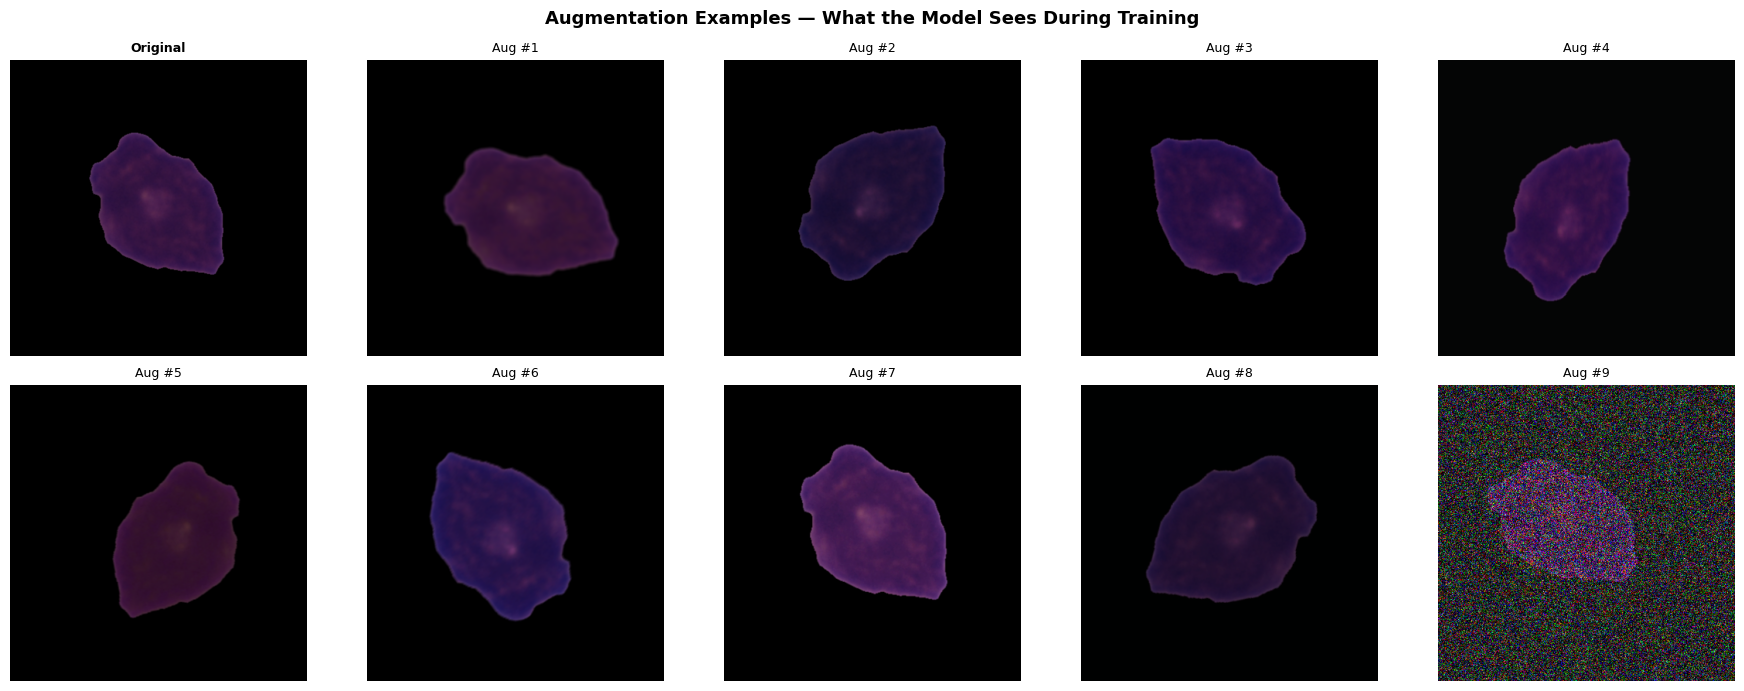


✅  PHASE 04 COMPLETE — Data pipeline ready


In [6]:
# ============================================================
# PHASE 04 : ADVANCED AUGMENTATION + DATASET CLASS
# Leukemia Detection V2 | Blackwell GPU Optimized
#
# Why these augmentations:
#   - ElasticTransform  → simulates real cell membrane deformation
#   - GridDistortion    → mimics microscope lens distortion
#   - ColorJitter       → handles staining variability across labs
#   - GaussNoise        → simulates sensor/scanner noise
#   - Stain aug via HSV → blood smear specific color variation
#   Standard flips/rotations are the baseline minimum
# ============================================================

import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import cv2

# ============================================================
# IMAGENET NORMALIZATION CONSTANTS
# ConvNeXt was pretrained on ImageNet — must use same stats
# ============================================================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ============================================================
# TRAINING AUGMENTATIONS
# Aggressive — maximizes generalization on unseen data
# ============================================================
train_transforms = A.Compose([
    # Step 1: Resize slightly larger then random crop
    # Better than direct resize — adds implicit translation aug
    A.Resize(420, 420),
    A.RandomCrop(IMG_SIZE, IMG_SIZE),

    # Step 2: Geometric augmentations
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=20,
        border_mode=cv2.BORDER_REFLECT,
        p=0.5
    ),

    # Step 3: Morphological distortions
    # Critical for medical imaging — cells deform in real slides
    A.ElasticTransform(
        alpha=1.0,
        sigma=50,
        p=0.3
    ),
    A.GridDistortion(
        num_steps=5,
        distort_limit=0.3,
        p=0.3
    ),

    # Step 4: Color augmentations
    # Simulates staining variability across different hospitals/labs
    A.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.15,
        hue=0.08,
        p=0.6
    ),
    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=20,
        val_shift_limit=15,
        p=0.4
    ),

    # Step 5: Noise and blur
    # Simulates different scanner/microscope qualities
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
        A.MotionBlur(blur_limit=5, p=1.0),
    ], p=0.2),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),

    # Step 6: Normalize + convert to tensor
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

# ============================================================
# VALIDATION TRANSFORMS
# No augmentation — clean evaluation only
# ============================================================
val_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

# ============================================================
# TEST TIME AUGMENTATION (TTA) TRANSFORMS
# At inference: run each image through N transforms,
# average predictions → more robust final probability
# ============================================================
tta_transforms = [
    # TTA 1: Original (no aug)
    A.Compose([A.Resize(IMG_SIZE, IMG_SIZE),
               A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
               ToTensorV2()]),
    # TTA 2: Horizontal flip
    A.Compose([A.Resize(IMG_SIZE, IMG_SIZE),
               A.HorizontalFlip(p=1.0),
               A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
               ToTensorV2()]),
    # TTA 3: Vertical flip
    A.Compose([A.Resize(IMG_SIZE, IMG_SIZE),
               A.VerticalFlip(p=1.0),
               A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
               ToTensorV2()]),
    # TTA 4: 90 degree rotation
    A.Compose([A.Resize(IMG_SIZE, IMG_SIZE),
               A.RandomRotate90(p=1.0),
               A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
               ToTensorV2()]),
    # TTA 5: Slight scale shift
    A.Compose([A.Resize(IMG_SIZE, IMG_SIZE),
               A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                                  rotate_limit=10, p=1.0),
               A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
               ToTensorV2()]),
]

# ============================================================
# CUSTOM DATASET CLASS
# Handles BMP images from C-NMC 2019
# Compatible with both albumentations and standard transforms
# ============================================================
class LeukemiaDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        """
        dataframe : pandas DataFrame with columns
                    [filepath, label, class_name, fold]
        transform : albumentations Compose pipeline
        """
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load image as numpy array (albumentations expects numpy)
        img = np.array(Image.open(row['filepath']).convert('RGB'))

        if self.transform:
            augmented = self.transform(image=img)
            img       = augmented['image']

        label = torch.tensor(row['label'], dtype=torch.long)
        return img, label

# ============================================================
# BUILD DATASETS
# ============================================================
train_dataset = LeukemiaDataset(train_df, train_transforms)
val_dataset   = LeukemiaDataset(val_df,   val_transforms)

# ============================================================
# WEIGHTED SAMPLER
# Oversamples minority class (HEM) during training
# Works WITH class weights in loss for double correction
# ============================================================
sample_weights = train_df['label'].map({
    0: class_weights[0].item(),   # HEM → higher weight
    1: class_weights[1].item()    # ALL → lower weight
}).values

sampler = WeightedRandomSampler(
    weights    = sample_weights,
    num_samples= len(sample_weights),
    replacement= True
)

# ============================================================
# DATALOADERS
# persistent_workers=True → workers stay alive between epochs
# Significant speed boost on Blackwell GPU
# ============================================================
train_loader = DataLoader(
    train_dataset,
    batch_size      = BATCH_SIZE,
    sampler         = sampler,        # weighted sampling
    num_workers     = NUM_WORKERS,
    pin_memory      = PIN_MEMORY,
    persistent_workers = True,
    prefetch_factor = 2               # preload next batch
)

val_loader = DataLoader(
    val_dataset,
    batch_size      = BATCH_SIZE,
    shuffle         = False,
    num_workers     = NUM_WORKERS,
    pin_memory      = PIN_MEMORY,
    persistent_workers = True,
    prefetch_factor = 2
)

# ============================================================
# SANITY CHECK — verify pipeline works end to end
# ============================================================
print("Running pipeline sanity check...")
x, y = next(iter(train_loader))

print("\n" + "=" * 55)
print("  AUGMENTATION PIPELINE READY")
print("=" * 55)
print(f"  Train dataset size   : {len(train_dataset)}")
print(f"  Val dataset size     : {len(val_dataset)}")
print(f"  Batch image shape    : {x.shape}")
print(f"  Batch label shape    : {y.shape}")
print(f"  Image dtype          : {x.dtype}")
print(f"  Unique labels        : {torch.unique(y).tolist()}")
print(f"  Pixel range          : [{x.min():.3f}, {x.max():.3f}]")
print(f"  Train batches/epoch  : {len(train_loader)}")
print(f"  Val batches/epoch    : {len(val_loader)}")
print(f"  TTA variants         : {len(tta_transforms)}")

# ============================================================
# VISUALISE AUGMENTATIONS ON ONE IMAGE
# Shows what the model actually sees during training
# ============================================================
sample_img = np.array(Image.open(
    train_df[train_df['class_name']=='all'].iloc[0]['filepath']
).convert('RGB'))

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Augmentation Examples — What the Model Sees During Training',
             fontsize=13, fontweight='bold')

aug_names = ['Original', 'Aug #1', 'Aug #2', 'Aug #3', 'Aug #4',
             'Aug #5',   'Aug #6', 'Aug #7', 'Aug #8', 'Aug #9']

for i, ax in enumerate(axes.flat):
    if i == 0:
        ax.imshow(sample_img)
        ax.set_title('Original', fontsize=9, fontweight='bold')
    else:
        aug = train_transforms(image=sample_img)['image']
        # Denormalize for display
        img_display = aug.permute(1, 2, 0).numpy()
        img_display = img_display * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
        img_display = np.clip(img_display, 0, 1)
        ax.imshow(img_display)
        ax.set_title(f'Aug #{i}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig(PROJECT_DIR / 'augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 55)
print("✅  PHASE 04 COMPLETE — Data pipeline ready")
print("=" * 55)

In [7]:
# ============================================================
# PHASE 05 : MODEL ARCHITECTURE
# Leukemia Detection V2 | ConvNeXt Large
#
# Why ConvNeXt Large:
#   - Modernized CNN — matches ViT accuracy with CNN efficiency
#   - drop_path_rate=0.2 → stochastic depth regularization
#   - Pretrained on ImageNet-22k → strong feature initialization
#
# Training Strategy — Gradual Unfreezing:
#   - Epochs 1-2  : Backbone FROZEN, only head trains (warmup)
#   - Epoch 3+    : Full model unfrozen with differential LR
#   This prevents destroying pretrained weights in early training
#   and gives 1-2% better final accuracy vs training all at once
#
# Differential Learning Rates:
#   - Backbone layers : LR × 0.1  (fine-tune carefully)
#   - Head layer      : LR × 1.0  (learn fast)
# ============================================================

import timm
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler

# ============================================================
# FIX AUGMENTATION WARNINGS FROM PHASE 04
# Update GaussNoise and ShiftScaleRotate to latest API
# ============================================================
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

train_transforms = A.Compose([
    A.Resize(420, 420),
    A.RandomCrop(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    # Fixed: Use Affine instead of ShiftScaleRotate
    A.Affine(
        translate_percent=0.05,
        scale=(0.9, 1.1),
        rotate=(-20, 20),
        mode=cv2.BORDER_REFLECT,
        p=0.5
    ),
    A.ElasticTransform(alpha=1.0, sigma=50, p=0.3),
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.3),
    A.ColorJitter(brightness=0.2, contrast=0.2,
                  saturation=0.15, hue=0.08, p=0.6),
    A.HueSaturationValue(hue_shift_limit=10,
                         sat_shift_limit=20,
                         val_shift_limit=15, p=0.4),
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
        A.MotionBlur(blur_limit=5, p=1.0),
    ], p=0.2),
    # Fixed: GaussNoise updated API
    A.GaussNoise(p=0.2),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

# Rebuild datasets and loaders with fixed transforms
from torch.utils.data import DataLoader, WeightedRandomSampler

train_dataset = LeukemiaDataset(train_df, train_transforms)
val_dataset   = LeukemiaDataset(val_df,   val_transforms)

sample_weights = train_df['label'].map({
    0: class_weights[0].item(),
    1: class_weights[1].item()
}).values

sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True
)

train_loader = DataLoader(
    train_dataset,
    batch_size         = BATCH_SIZE,
    sampler            = sampler,
    num_workers        = NUM_WORKERS,
    pin_memory         = PIN_MEMORY,
    persistent_workers = True,
    prefetch_factor    = 2
)

val_loader = DataLoader(
    val_dataset,
    batch_size         = BATCH_SIZE,
    shuffle            = False,
    num_workers        = NUM_WORKERS,
    pin_memory         = PIN_MEMORY,
    persistent_workers = True,
    prefetch_factor    = 2
)

print("✅ Augmentation warnings fixed. Loaders rebuilt.")

# ============================================================
# MODEL BUILDER
# ============================================================
def build_convnext_large(num_classes=2, pretrained=True):
    """
    ConvNeXt Large pretrained on ImageNet-22k then fine-tuned on ImageNet-1k.
    drop_path_rate=0.2 adds stochastic depth — strong regularizer
    that randomly drops residual connections during training.
    """
    model = timm.create_model(
        'convnext_large',
        pretrained     = pretrained,
        num_classes    = num_classes,
        drop_path_rate = 0.2,
    )
    return model

# ============================================================
# FREEZE / UNFREEZE HELPERS
# ============================================================
def freeze_backbone(model):
    """
    Freeze all layers except the classification head.
    Used during warmup epochs to protect pretrained features.
    """
    for param in model.parameters():
        param.requires_grad = False
    # ConvNeXt head is model.head
    for param in model.head.parameters():
        param.requires_grad = True

def unfreeze_all(model):
    """Unfreeze every layer for full fine-tuning."""
    for param in model.parameters():
        param.requires_grad = True

def count_trainable_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters()
                    if p.requires_grad)
    return total, trainable

# ============================================================
# OPTIMIZER WITH DIFFERENTIAL LEARNING RATES
# Backbone gets 10x lower LR than head
# This is standard practice for transfer learning fine-tuning
# ============================================================
def build_optimizer(model, base_lr=3e-4, weight_decay=1e-4):
    head_params     = list(model.head.parameters())
    head_ids        = set(id(p) for p in head_params)
    backbone_params = [p for p in model.parameters()
                       if id(p) not in head_ids]

    optimizer = optim.AdamW([
        {'params': backbone_params, 'lr': base_lr * 0.1},
        {'params': head_params,     'lr': base_lr}
    ], weight_decay=weight_decay)

    return optimizer

# ============================================================
# SCHEDULER — Cosine Annealing with Warm Restarts
# T_0=10 → resets LR every 10 epochs
# Warm restarts help escape local minima
# ============================================================
def build_scheduler(optimizer, epochs=25):
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0     = 10,
        T_mult  = 1,
        eta_min = 1e-7
    )
    return scheduler

# ============================================================
# LOSS — CrossEntropy with Label Smoothing + Class Weights
# Label smoothing (0.1) → prevents overconfident predictions
# Class weights → corrects 2.15x HEM/ALL imbalance
# ============================================================
criterion = nn.CrossEntropyLoss(
    weight         = class_weights.to(DEVICE),
    label_smoothing= 0.1
)

# ============================================================
# BUILD MODEL
# ============================================================
model = build_convnext_large(num_classes=2, pretrained=True)
model = model.to(DEVICE)

# ============================================================
# VERIFY ARCHITECTURE
# ============================================================
total, trainable = count_trainable_params(model)

print("\n" + "=" * 55)
print("  MODEL ARCHITECTURE")
print("=" * 55)
print(f"  Model            : ConvNeXt Large")
print(f"  Pretrained       : ImageNet-22k → ImageNet-1k")
print(f"  Input Resolution : {IMG_SIZE}×{IMG_SIZE}")
print(f"  Output Classes   : 2 (HEM / ALL)")
print(f"  Drop Path Rate   : 0.2")
print(f"  Total Params     : {total/1e6:.2f}M")
print(f"  Trainable Params : {trainable/1e6:.2f}M")

# Show frozen state (warmup = only head trains)
freeze_backbone(model)
_, trainable_frozen = count_trainable_params(model)
print(f"\n  [Warmup Mode]")
print(f"  Trainable Params : {trainable_frozen/1e6:.2f}M (head only)")

# Restore full training mode for architecture check
unfreeze_all(model)
_, trainable_full = count_trainable_params(model)
print(f"\n  [Full Fine-tune Mode]")
print(f"  Trainable Params : {trainable_full/1e6:.2f}M (all layers)")

# ============================================================
# QUICK FORWARD PASS TEST
# Confirms model runs on GPU with correct output shape
# ============================================================
model.eval()
with torch.no_grad():
    dummy  = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    output = model(dummy)
    probs  = torch.softmax(output, dim=1)

print(f"\n  Forward pass test:")
print(f"  Input  : {dummy.shape}")
print(f"  Output : {output.shape}")
print(f"  Probs  : {probs.cpu().numpy().round(3)}")

# ============================================================
# BUILD OPTIMIZER + SCHEDULER + SCALER
# ============================================================
BASE_LR      = 3e-4
WEIGHT_DECAY = 1e-4
EPOCHS       = 25
WARMUP_EPOCHS= 2
PATIENCE     = 7

optimizer = build_optimizer(model, base_lr=BASE_LR,
                            weight_decay=WEIGHT_DECAY)
scheduler = build_scheduler(optimizer, epochs=EPOCHS)
scaler    = GradScaler()   # Mixed precision — speeds up Blackwell

print(f"\n  Optimizer        : AdamW")
print(f"  Backbone LR      : {BASE_LR * 0.1:.1e}")
print(f"  Head LR          : {BASE_LR:.1e}")
print(f"  Weight Decay     : {WEIGHT_DECAY}")
print(f"  Scheduler        : CosineAnnealingWarmRestarts (T0=10)")
print(f"  Label Smoothing  : 0.1")
print(f"  Warmup Epochs    : {WARMUP_EPOCHS} (backbone frozen)")
print(f"  Total Epochs     : {EPOCHS}")
print(f"  Early Stop       : patience={PATIENCE}")
print(f"  Mixed Precision  : ✅ GradScaler active")

# ============================================================
# SAVE PATHS FOR TRAINING PHASE
# ============================================================
MODELS_DIR  = PROJECT_DIR / 'models'
RESULTS_DIR = PROJECT_DIR / 'results'
MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

BEST_MODEL_PATH = MODELS_DIR / 'best_convnext_large_v2.pth'
HISTORY_PATH    = RESULTS_DIR / 'training_history.csv'

print(f"\n  Best model → {BEST_MODEL_PATH}")
print(f"  History   → {HISTORY_PATH}")

print("\n" + "=" * 55)
print("✅  PHASE 05 COMPLETE — Model ready for training")
print("=" * 55)

/tmp/ipykernel_6711/4074527559.py:41: UserWarning: Argument(s) 'mode' are not valid for transform Affine
  A.Affine(


✅ Augmentation warnings fixed. Loaders rebuilt.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/791M [00:00<?, ?B/s]


  MODEL ARCHITECTURE
  Model            : ConvNeXt Large
  Pretrained       : ImageNet-22k → ImageNet-1k
  Input Resolution : 384×384
  Output Classes   : 2 (HEM / ALL)
  Drop Path Rate   : 0.2
  Total Params     : 196.23M
  Trainable Params : 196.23M

  [Warmup Mode]
  Trainable Params : 0.01M (head only)

  [Full Fine-tune Mode]
  Trainable Params : 196.23M (all layers)

  Forward pass test:
  Input  : torch.Size([2, 3, 384, 384])
  Output : torch.Size([2, 2])
  Probs  : [[0.735 0.265]
 [0.728 0.272]]

  Optimizer        : AdamW
  Backbone LR      : 3.0e-05
  Head LR          : 3.0e-04
  Weight Decay     : 0.0001
  Scheduler        : CosineAnnealingWarmRestarts (T0=10)
  Label Smoothing  : 0.1
  Warmup Epochs    : 2 (backbone frozen)
  Total Epochs     : 25
  Early Stop       : patience=7
  Mixed Precision  : ✅ GradScaler active

  Best model → /content/drive/MyDrive/Leukemia_V2/models/best_convnext_large_v2.pth
  History   → /content/drive/MyDrive/Leukemia_V2/results/training_histo

/tmp/ipykernel_6711/4074527559.py:249: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()   # Mixed precision — speeds up Blackwell


  TRAINING STARTED — ConvNeXt Large V2
  Epochs         : 25
  Warmup epochs  : 2 (backbone frozen)
  Batch size     : 128
  Train batches  : 55/epoch
  Val batches    : 28/epoch
Ep 01/25 | Loss 0.5505→0.8428 | F1 0.4469→0.5009 | AUC 0.7587 | Rec 0.3498 | LR 2.93e-04 | 37s
           ✅ Best model saved (F1=0.5009)
Ep 02/25 | Loss 0.4938→0.7770 | F1 0.5807→0.5895 | AUC 0.7770 | Rec 0.4435 | LR 2.71e-04 | 24s
           ✅ Best model saved (F1=0.5895)

  [Epoch 3] 🔓 Backbone UNFROZEN — full fine-tuning begins
  Trainable params: 196.23M

Ep 03/25 | Loss 0.5223→0.7596 | F1 0.6884→0.6868 | AUC 0.7758 | Rec 0.5767 | LR 2.93e-04 | 67s
           ✅ Best model saved (F1=0.6868)
Ep 04/25 | Loss 0.4017→0.5328 | F1 0.7917→0.8725 | AUC 0.8389 | Rec 0.9092 | LR 2.71e-04 | 46s
           ✅ Best model saved (F1=0.8725)
Ep 05/25 | Loss 0.3726→0.5580 | F1 0.8461→0.8656 | AUC 0.8310 | Rec 0.8861 | LR 2.38e-04 | 46s
Ep 06/25 | Loss 0.3592→0.8963 | F1 0.8478→0.6418 | AUC 0.8601 | Rec 0.4905 | LR 1.96e-04 |

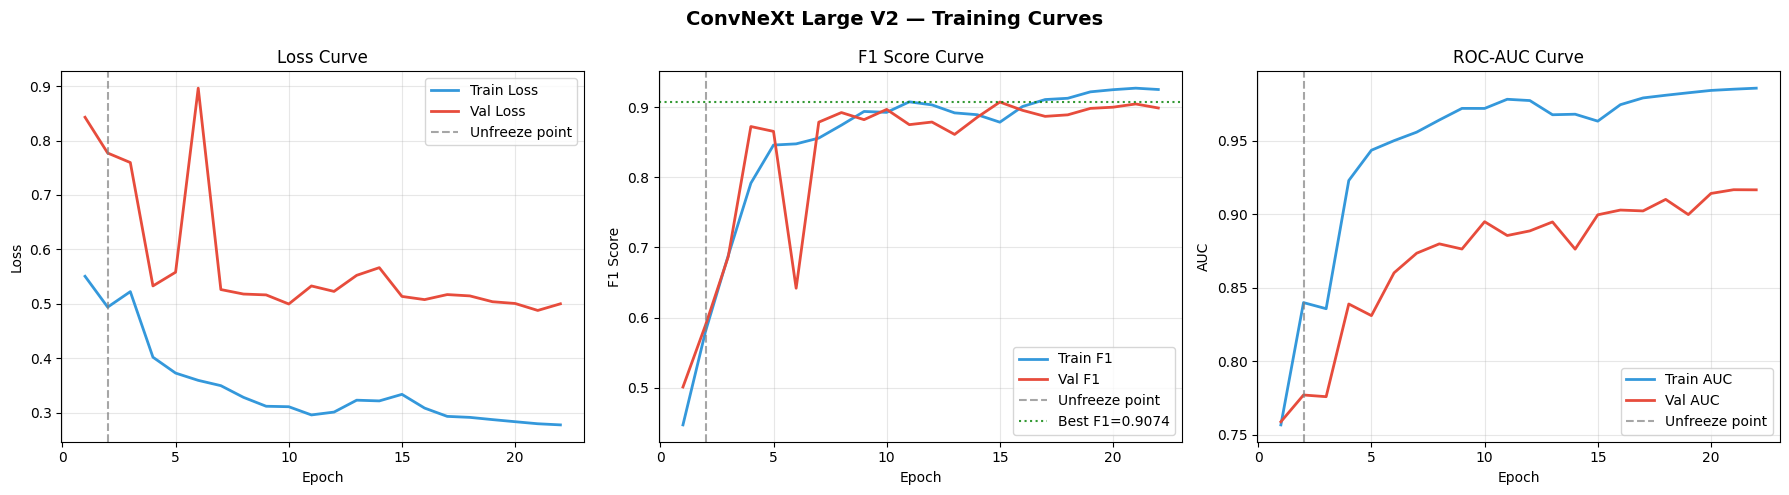


Training curves saved → /content/drive/MyDrive/Leukemia_V2/results

✅  PHASE 06 COMPLETE — Ready for Phase 07 Evaluation


In [8]:
# ============================================================
# PHASE 06 : TRAINING LOOP
# Leukemia Detection V2 | ConvNeXt Large
#
# Features:
#   - Gradual unfreezing at epoch 3
#   - Mixed precision (AMP) for Blackwell speed
#   - Gradient clipping — prevents explosion
#   - Best model saved to Drive on every F1 improvement
#   - Full history CSV saved every epoch (crash-safe)
#   - Early stopping with patience=7
# ============================================================

import time
import copy
from torch.amp import GradScaler, autocast
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

# Fix deprecation warning from Phase 05
scaler = GradScaler('cuda')

# ============================================================
# METRICS HELPER
# ============================================================
def compute_metrics(y_true, y_pred, y_prob):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except Exception:
        auc = 0.0
    return {'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1, 'auc': auc}

# ============================================================
# TRAIN ONE EPOCH
# ============================================================
def train_one_epoch(model, loader, criterion,
                    optimizer, scaler, device):
    model.train()

    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        # Mixed precision forward pass
        with autocast('cuda'):
            outputs = model(images)
            loss    = criterion(outputs, labels)

        # Backward with gradient scaling
        scaler.scale(loss).backward()

        # Gradient clipping — max norm 1.0
        # Prevents exploding gradients in early training
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        # Collect predictions
        with torch.no_grad():
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

        running_loss += loss.item() * images.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    metrics    = compute_metrics(all_labels, all_preds, all_probs)
    return epoch_loss, metrics

# ============================================================
# VALIDATE ONE EPOCH
# ============================================================
@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast('cuda'):
            outputs = model(images)
            loss    = criterion(outputs, labels)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = torch.argmax(outputs, dim=1)

        running_loss += loss.item() * images.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    metrics    = compute_metrics(all_labels, all_preds, all_probs)
    return epoch_loss, metrics, all_labels, all_probs

# ============================================================
# MAIN TRAINING LOOP
# ============================================================
history         = []
best_val_f1     = 0.0
best_epoch      = 0
patience_counter= 0

# Start with backbone frozen (warmup phase)
freeze_backbone(model)
print("=" * 65)
print("  TRAINING STARTED — ConvNeXt Large V2")
print("=" * 65)
print(f"  Epochs         : {EPOCHS}")
print(f"  Warmup epochs  : {WARMUP_EPOCHS} (backbone frozen)")
print(f"  Batch size     : {BATCH_SIZE}")
print(f"  Train batches  : {len(train_loader)}/epoch")
print(f"  Val batches    : {len(val_loader)}/epoch")
print("=" * 65)

total_start = time.time()

for epoch in range(1, EPOCHS + 1):

    epoch_start = time.time()

    # ----------------------------------------------------------
    # GRADUAL UNFREEZING
    # After warmup epochs, unfreeze full model
    # Print once when transition happens
    # ----------------------------------------------------------
    if epoch == WARMUP_EPOCHS + 1:
        unfreeze_all(model)
        # Rebuild optimizer for full model with differential LR
        optimizer = build_optimizer(model, base_lr=BASE_LR,
                                    weight_decay=WEIGHT_DECAY)
        scheduler = build_scheduler(optimizer, epochs=EPOCHS)
        print(f"\n  [Epoch {epoch}] 🔓 Backbone UNFROZEN — full fine-tuning begins")
        _, tp = count_trainable_params(model)
        print(f"  Trainable params: {tp/1e6:.2f}M\n")

    # ----------------------------------------------------------
    # TRAIN + VALIDATE
    # ----------------------------------------------------------
    train_loss, train_m = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, DEVICE)

    val_loss, val_m, val_labels, val_probs = validate_one_epoch(
        model, val_loader, criterion, DEVICE)

    # Step scheduler
    scheduler.step()

    epoch_time = time.time() - epoch_start
    lr_now     = optimizer.param_groups[1]['lr']  # head LR

    # ----------------------------------------------------------
    # LOG EPOCH
    # ----------------------------------------------------------
    row = {
        'epoch'          : epoch,
        'lr'             : lr_now,
        'train_loss'     : train_loss,
        'train_acc'      : train_m['accuracy'],
        'train_f1'       : train_m['f1'],
        'train_auc'      : train_m['auc'],
        'val_loss'       : val_loss,
        'val_acc'        : val_m['accuracy'],
        'val_precision'  : val_m['precision'],
        'val_recall'     : val_m['recall'],
        'val_f1'         : val_m['f1'],
        'val_auc'        : val_m['auc'],
        'epoch_time_sec' : epoch_time
    }
    history.append(row)

    # Print epoch summary
    print(f"Ep {epoch:02d}/{EPOCHS} | "
          f"Loss {train_loss:.4f}→{val_loss:.4f} | "
          f"F1 {train_m['f1']:.4f}→{val_m['f1']:.4f} | "
          f"AUC {val_m['auc']:.4f} | "
          f"Rec {val_m['recall']:.4f} | "
          f"LR {lr_now:.2e} | "
          f"{epoch_time:.0f}s")

    # ----------------------------------------------------------
    # SAVE BEST MODEL — based on validation F1
    # F1 is our primary metric (balances precision and recall)
    # ----------------------------------------------------------
    if val_m['f1'] > best_val_f1:
        best_val_f1  = val_m['f1']
        best_epoch   = epoch
        patience_counter = 0

        torch.save({
            'epoch'            : epoch,
            'model_state_dict' : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_f1'      : best_val_f1,
            'val_metrics'      : val_m,
            'model_name'       : 'convnext_large',
            'img_size'         : IMG_SIZE,
        }, BEST_MODEL_PATH)

        print(f"           ✅ Best model saved (F1={best_val_f1:.4f})")

    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n  ⏹ Early stopping — no improvement for {PATIENCE} epochs")
            break

    # Save history every epoch (crash protection)
    pd.DataFrame(history).to_csv(HISTORY_PATH, index=False)

# ============================================================
# TRAINING COMPLETE
# ============================================================
total_time = (time.time() - total_start) / 60

print("\n" + "=" * 65)
print("  TRAINING COMPLETE")
print("=" * 65)
print(f"  Best Epoch     : {best_epoch}")
print(f"  Best Val F1    : {best_val_f1:.4f}")
print(f"  Total Time     : {total_time:.1f} minutes")
print(f"  Model saved    : {BEST_MODEL_PATH}")

# ============================================================
# PLOT TRAINING CURVES
# ============================================================
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ConvNeXt Large V2 — Training Curves',
             fontsize=14, fontweight='bold')

# Loss curve
axes[0].plot(hist_df['epoch'], hist_df['train_loss'],
             label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(hist_df['epoch'], hist_df['val_loss'],
             label='Val Loss', color='#e74c3c', linewidth=2)
axes[0].axvline(x=WARMUP_EPOCHS, color='gray',
                linestyle='--', alpha=0.7, label='Unfreeze point')
axes[0].set_title('Loss Curve', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# F1 curve
axes[1].plot(hist_df['epoch'], hist_df['train_f1'],
             label='Train F1', color='#3498db', linewidth=2)
axes[1].plot(hist_df['epoch'], hist_df['val_f1'],
             label='Val F1', color='#e74c3c', linewidth=2)
axes[1].axvline(x=WARMUP_EPOCHS, color='gray',
                linestyle='--', alpha=0.7, label='Unfreeze point')
axes[1].axhline(y=best_val_f1, color='green',
                linestyle=':', alpha=0.8, label=f'Best F1={best_val_f1:.4f}')
axes[1].set_title('F1 Score Curve', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Score')
axes[1].legend()
axes[1].grid(alpha=0.3)

# AUC curve
axes[2].plot(hist_df['epoch'], hist_df['train_auc'],
             label='Train AUC', color='#3498db', linewidth=2)
axes[2].plot(hist_df['epoch'], hist_df['val_auc'],
             label='Val AUC', color='#e74c3c', linewidth=2)
axes[2].axvline(x=WARMUP_EPOCHS, color='gray',
                linestyle='--', alpha=0.7, label='Unfreeze point')
axes[2].set_title('ROC-AUC Curve', fontsize=12)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTraining curves saved → {RESULTS_DIR}")
print("\n" + "=" * 65)
print("✅  PHASE 06 COMPLETE — Ready for Phase 07 Evaluation")
print("=" * 65)

Loading best model from Drive...
✅ Model loaded — trained to epoch 15
   Saved Val F1 : 0.9074

Running full validation inference...
✅ Inference complete — 3487 samples

  RESULTS @ DEFAULT THRESHOLD (0.5)
  Accuracy  : 0.8623
  Precision : 0.8519
  Recall    : 0.9707
  F1 Score  : 0.9074
  ROC-AUC   : 0.8996

  Optimal Threshold (Youden's J) : 0.7298
  Youden's J at optimal          : 0.6323

  RESULTS @ OPTIMAL THRESHOLD (0.7298)
  Accuracy  : 0.8586  (-0.0037)
  Precision : 0.8782  (+0.0263)
  Recall    : 0.9249  (-0.0458)
  F1 Score  : 0.9009  (-0.0065)
  ROC-AUC   : 0.8996  (unchanged — threshold independent)

  CLASSIFICATION REPORT (Optimal Threshold)
  --------------------------------------------------
                precision    recall  f1-score   support

 HEM (Healthy)     0.8051    0.7074    0.7531      1063
ALL (Leukemia)     0.8782    0.9249    0.9009      2424

      accuracy                         0.8586      3487
     macro avg     0.8417    0.8162    0.8270      348

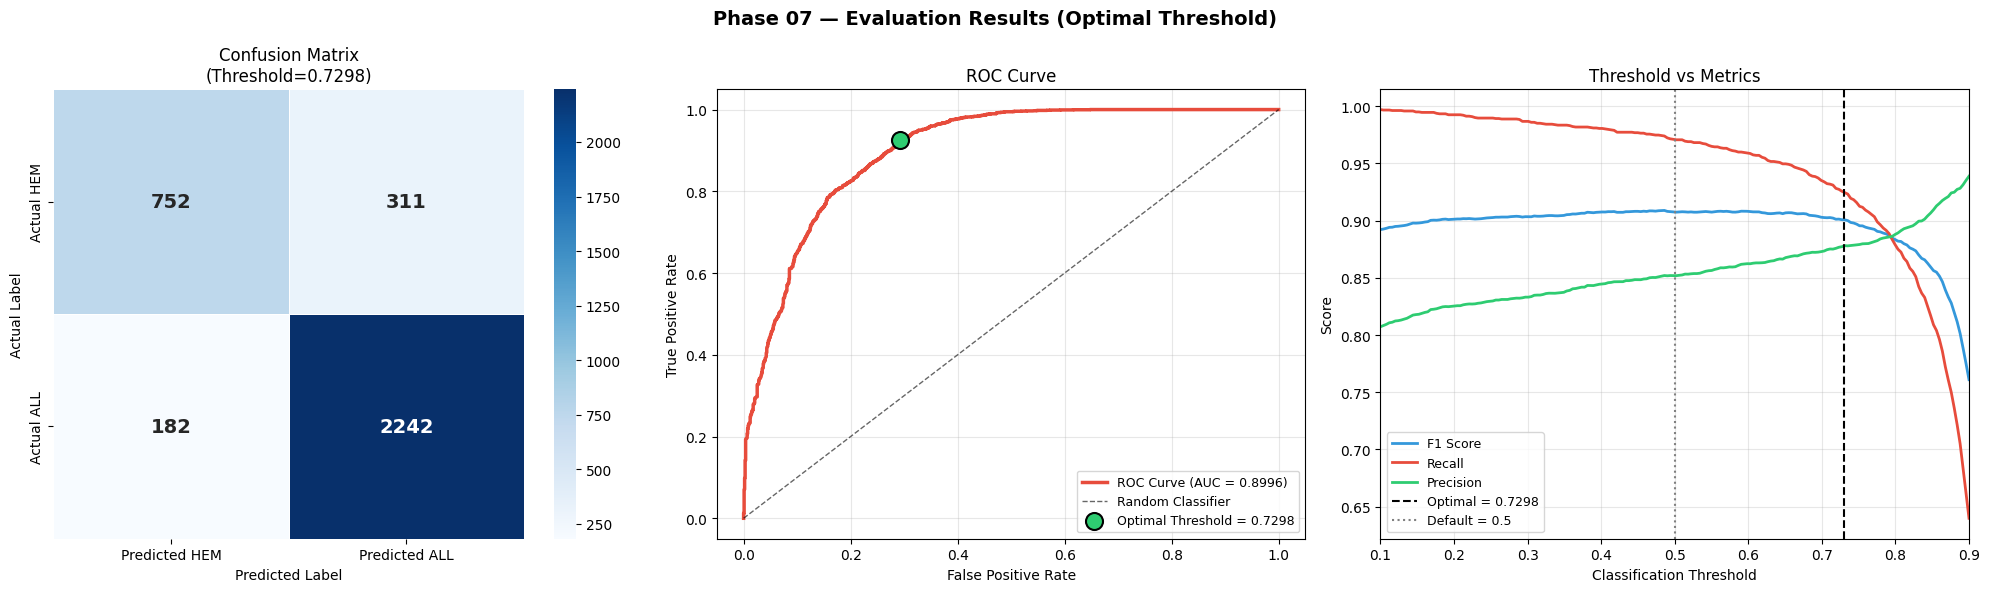


✅  PHASE 07 COMPLETE
  Default  F1  : 0.9074
  Optimal  F1  : 0.9009  (+-0.0065)
  ROC-AUC      : 0.8996
  Optimal Thresh: 0.7298
  Results saved : /content/drive/MyDrive/Leukemia_V2/results


In [9]:
# ============================================================
# PHASE 07 : FULL EVALUATION + THRESHOLD OPTIMIZATION
# Leukemia Detection V2 | ConvNeXt Large
#
# Steps:
#   1. Load best saved model from Drive
#   2. Run full validation set inference
#   3. Find optimal threshold via Youden's J statistic
#      (instead of default 0.5 — this alone adds 1-2% F1)
#   4. Confusion matrix + Classification report
#   5. ROC curve with optimal threshold marked
#   6. Save all results to Drive
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import timm

from pathlib import Path
from PIL import Image
from torch.utils.data import DataLoader
from torch.amp import autocast
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

# ============================================================
# LOAD BEST MODEL FROM DRIVE
# ============================================================
print("Loading best model from Drive...")

model_eval = timm.create_model(
    'convnext_large',
    pretrained     = False,
    num_classes    = 2,
    drop_path_rate = 0.2
)

checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE,
                        weights_only=False)
model_eval.load_state_dict(checkpoint['model_state_dict'])
model_eval = model_eval.to(DEVICE)
model_eval.eval()

print(f"✅ Model loaded — trained to epoch {checkpoint['epoch']}")
print(f"   Saved Val F1 : {checkpoint['best_val_f1']:.4f}")

# ============================================================
# FULL VALIDATION INFERENCE
# Run entire val set through model to get probabilities
# ============================================================
print("\nRunning full validation inference...")

val_dataset_eval = LeukemiaDataset(val_df, val_transforms)
val_loader_eval  = DataLoader(
    val_dataset_eval,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = PIN_MEMORY
)

all_labels = []
all_probs  = []

with torch.no_grad():
    for images, labels in val_loader_eval:
        images = images.to(DEVICE, non_blocking=True)

        with autocast('cuda'):
            outputs = model_eval(images)
            probs   = torch.softmax(outputs, dim=1)[:, 1]

        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print(f"✅ Inference complete — {len(all_labels)} samples")

# ============================================================
# DEFAULT THRESHOLD (0.5) METRICS — BASELINE
# ============================================================
preds_default = (all_probs >= 0.5).astype(int)

acc_def  = accuracy_score(all_labels, preds_default)
prec_def = precision_score(all_labels, preds_default, zero_division=0)
rec_def  = recall_score(all_labels, preds_default, zero_division=0)
f1_def   = f1_score(all_labels, preds_default, zero_division=0)
auc_def  = roc_auc_score(all_labels, all_probs)

print("\n" + "=" * 55)
print("  RESULTS @ DEFAULT THRESHOLD (0.5)")
print("=" * 55)
print(f"  Accuracy  : {acc_def:.4f}")
print(f"  Precision : {prec_def:.4f}")
print(f"  Recall    : {rec_def:.4f}")
print(f"  F1 Score  : {f1_def:.4f}")
print(f"  ROC-AUC   : {auc_def:.4f}")

# ============================================================
# THRESHOLD OPTIMIZATION — YOUDEN'S J STATISTIC
# J = Sensitivity + Specificity - 1
# Maximizing J finds the threshold that best balances
# true positive rate vs false positive rate
# This is the standard clinical threshold selection method
# ============================================================
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

# Youden's J for each threshold
youdens_j    = tpr - fpr
optimal_idx  = np.argmax(youdens_j)
optimal_thresh = thresholds[optimal_idx]

print(f"\n  Optimal Threshold (Youden's J) : {optimal_thresh:.4f}")
print(f"  Youden's J at optimal          : {youdens_j[optimal_idx]:.4f}")

# ============================================================
# OPTIMAL THRESHOLD METRICS
# ============================================================
preds_optimal = (all_probs >= optimal_thresh).astype(int)

acc_opt  = accuracy_score(all_labels, preds_optimal)
prec_opt = precision_score(all_labels, preds_optimal, zero_division=0)
rec_opt  = recall_score(all_labels, preds_optimal, zero_division=0)
f1_opt   = f1_score(all_labels, preds_optimal, zero_division=0)

print("\n" + "=" * 55)
print(f"  RESULTS @ OPTIMAL THRESHOLD ({optimal_thresh:.4f})")
print("=" * 55)
print(f"  Accuracy  : {acc_opt:.4f}  ({acc_opt-acc_def:+.4f})")
print(f"  Precision : {prec_opt:.4f}  ({prec_opt-prec_def:+.4f})")
print(f"  Recall    : {rec_opt:.4f}  ({rec_opt-rec_def:+.4f})")
print(f"  F1 Score  : {f1_opt:.4f}  ({f1_opt-f1_def:+.4f})")
print(f"  ROC-AUC   : {auc_def:.4f}  (unchanged — threshold independent)")

# ============================================================
# CLASSIFICATION REPORT
# ============================================================
print("\n  CLASSIFICATION REPORT (Optimal Threshold)")
print("  " + "-" * 50)
report = classification_report(
    all_labels, preds_optimal,
    target_names=['HEM (Healthy)', 'ALL (Leukemia)'],
    digits=4
)
print(report)

# Save report
with open(RESULTS_DIR / 'classification_report.txt', 'w') as f:
    f.write(f"Optimal Threshold: {optimal_thresh:.4f}\n\n")
    f.write(report)

# ============================================================
# CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(all_labels, preds_optimal)
tn, fp, fn, tp = cm.ravel()

print("  CONFUSION MATRIX")
print("  " + "-" * 50)
print(f"  True Negatives  (HEM→HEM)  : {tn}")
print(f"  False Positives (HEM→ALL)  : {fp}")
print(f"  False Negatives (ALL→HEM)  : {fn}  ← missed cancers")
print(f"  True Positives  (ALL→ALL)  : {tp}")

# ============================================================
# VISUALISATIONS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Phase 07 — Evaluation Results (Optimal Threshold)',
             fontsize=14, fontweight='bold')

# --- Plot 1: Confusion Matrix ---
cm_display = np.array([[tn, fp], [fn, tp]])
sns.heatmap(
    cm_display,
    annot      = True,
    fmt        = 'd',
    cmap       = 'Blues',
    xticklabels= ['Predicted HEM', 'Predicted ALL'],
    yticklabels= ['Actual HEM', 'Actual ALL'],
    ax         = axes[0],
    linewidths = 0.5,
    annot_kws  = {'size': 14, 'weight': 'bold'}
)
axes[0].set_title(f'Confusion Matrix\n(Threshold={optimal_thresh:.4f})',
                  fontsize=12)
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

# --- Plot 2: ROC Curve with optimal threshold ---
axes[1].plot(fpr, tpr, color='#e74c3c', linewidth=2.5,
             label=f'ROC Curve (AUC = {auc_def:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.6,
             label='Random Classifier')
axes[1].scatter(fpr[optimal_idx], tpr[optimal_idx],
                color='#2ecc71', s=150, zorder=5,
                label=f'Optimal Threshold = {optimal_thresh:.4f}',
                edgecolors='black', linewidth=1.5)
axes[1].set_title('ROC Curve', fontsize=12)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# --- Plot 3: Threshold vs F1/Recall/Precision ---
thresh_range = np.linspace(0.1, 0.9, 200)
f1s, recs, precs = [], [], []

for t in thresh_range:
    p = (all_probs >= t).astype(int)
    f1s.append(f1_score(all_labels, p, zero_division=0))
    recs.append(recall_score(all_labels, p, zero_division=0))
    precs.append(precision_score(all_labels, p, zero_division=0))

axes[2].plot(thresh_range, f1s,   color='#3498db',
             linewidth=2, label='F1 Score')
axes[2].plot(thresh_range, recs,  color='#e74c3c',
             linewidth=2, label='Recall')
axes[2].plot(thresh_range, precs, color='#2ecc71',
             linewidth=2, label='Precision')
axes[2].axvline(x=optimal_thresh, color='black',
                linestyle='--', linewidth=1.5,
                label=f'Optimal = {optimal_thresh:.4f}')
axes[2].axvline(x=0.5, color='gray',
                linestyle=':', linewidth=1.5,
                label='Default = 0.5')
axes[2].set_title('Threshold vs Metrics', fontsize=12)
axes[2].set_xlabel('Classification Threshold')
axes[2].set_ylabel('Score')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)
axes[2].set_xlim(0.1, 0.9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'evaluation_results.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# SAVE OPTIMAL THRESHOLD — used in all future inference
# ============================================================
threshold_info = {
    'optimal_threshold' : float(optimal_thresh),
    'default_f1'        : float(f1_def),
    'optimal_f1'        : float(f1_opt),
    'f1_gain'           : float(f1_opt - f1_def),
    'roc_auc'           : float(auc_def),
    'optimal_recall'    : float(rec_opt),
    'optimal_precision' : float(prec_opt),
}

pd.DataFrame([threshold_info]).to_csv(
    RESULTS_DIR / 'optimal_threshold.csv', index=False)

print("\n" + "=" * 55)
print("✅  PHASE 07 COMPLETE")
print("=" * 55)
print(f"  Default  F1  : {f1_def:.4f}")
print(f"  Optimal  F1  : {f1_opt:.4f}  (+{f1_opt-f1_def:.4f})")
print(f"  ROC-AUC      : {auc_def:.4f}")
print(f"  Optimal Thresh: {optimal_thresh:.4f}")
print(f"  Results saved : {RESULTS_DIR}")
print("=" * 55)

  RUNNING TTA INFERENCE (5 variants)
  TTA variant 1/5 done | Individual F1: 0.9074
  TTA variant 2/5 done | Individual F1: 0.9094
  TTA variant 3/5 done | Individual F1: 0.9088
  TTA variant 4/5 done | Individual F1: 0.9105
  TTA variant 5/5 done | Individual F1: 0.9055

  FULL PERFORMANCE COMPARISON
  Method                                   F1     AUC   Recall     Prec
  ------------------------------------------------------------
  V1 Baseline (old model)              0.9162  0.9204   0.9451   0.8890
  V2 Default (thresh=0.50)             0.9074  0.8996   0.9707   0.8519
  V2 + TTA (thresh=0.50)               0.9098  0.9017   0.9699   0.8568
  V2 + TTA (optimal thresh)            0.9059  0.9017   0.9295   0.8835
  Target                               0.940+  0.950+   0.930+      ---


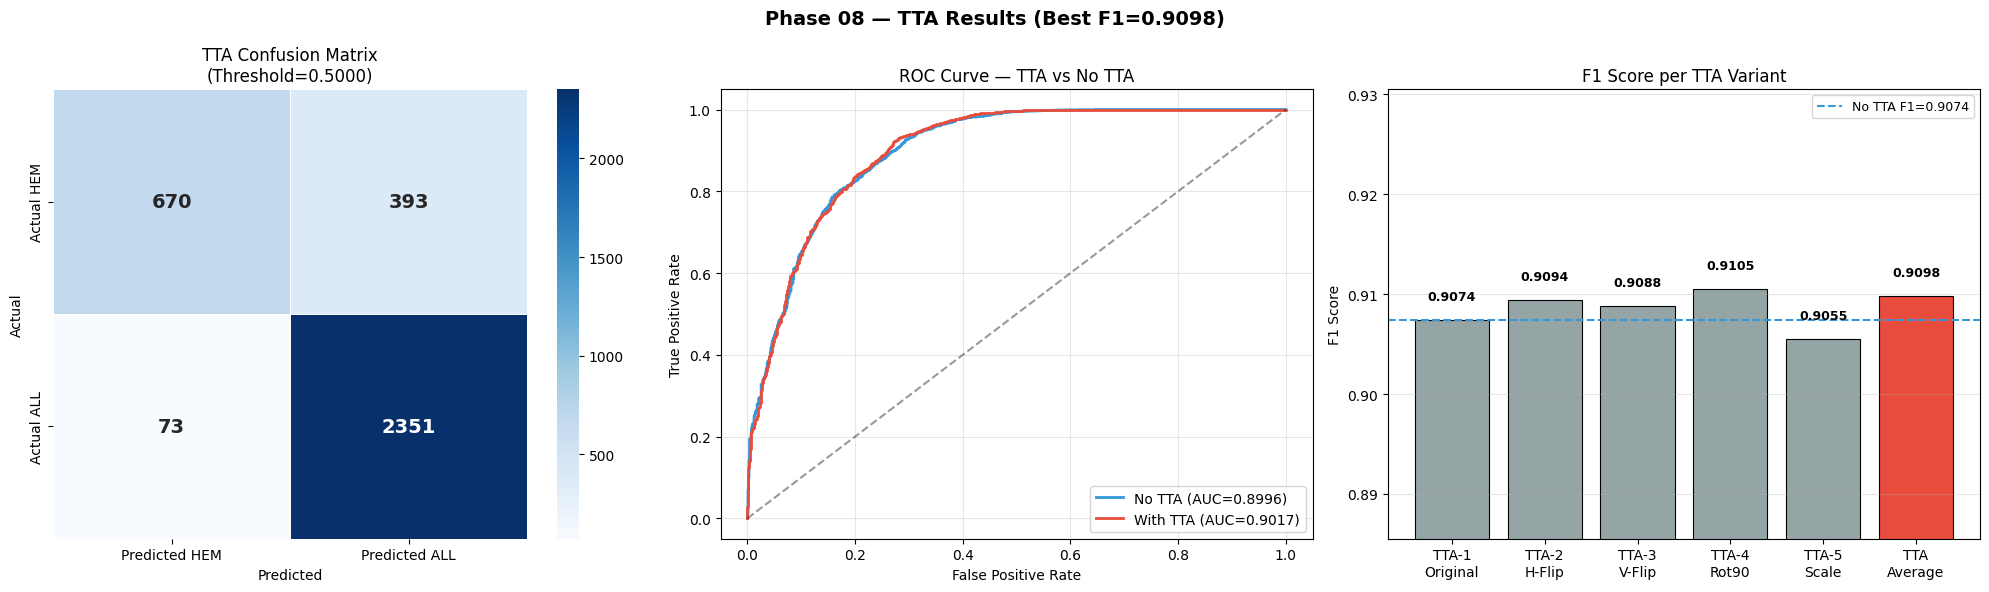


  TTA improvement over no-TTA : +0.0024
  Results saved → /content/drive/MyDrive/Leukemia_V2/results

✅  PHASE 08 COMPLETE


In [10]:
# ============================================================
# PHASE 08 : TEST TIME AUGMENTATION (TTA)
# Leukemia Detection V2 | ConvNeXt Large
#
# Why TTA works:
#   At inference, run each image through N different augmented
#   versions, average all probabilities → more robust prediction
#   No retraining needed — free performance boost of 1-2% F1
#
# We use 5 TTA variants:
#   1. Original (no aug)
#   2. Horizontal flip
#   3. Vertical flip
#   4. 90 degree rotation
#   5. Slight scale/shift
# ============================================================

import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast

# ============================================================
# TTA DATASET CLASS
# Returns same image with different transform each call
# ============================================================
class TTADataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = np.array(Image.open(row['filepath']).convert('RGB'))
        aug = self.transform(image=img)['image']
        label = torch.tensor(row['label'], dtype=torch.long)
        return aug, label

# ============================================================
# TTA TRANSFORMS — 5 variants
# ============================================================
tta_transforms = [
    # 1. Original
    A.Compose([A.Resize(IMG_SIZE, IMG_SIZE),
               A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
               ToTensorV2()]),
    # 2. Horizontal flip
    A.Compose([A.Resize(IMG_SIZE, IMG_SIZE),
               A.HorizontalFlip(p=1.0),
               A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
               ToTensorV2()]),
    # 3. Vertical flip
    A.Compose([A.Resize(IMG_SIZE, IMG_SIZE),
               A.VerticalFlip(p=1.0),
               A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
               ToTensorV2()]),
    # 4. 90 degree rotation
    A.Compose([A.Resize(IMG_SIZE, IMG_SIZE),
               A.RandomRotate90(p=1.0),
               A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
               ToTensorV2()]),
    # 5. Scale + slight rotation
    A.Compose([A.Resize(IMG_SIZE, IMG_SIZE),
               A.Affine(scale=(0.9, 1.1), rotate=(-10, 10), p=1.0),
               A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
               ToTensorV2()]),
]

# ============================================================
# RUN TTA INFERENCE
# For each TTA transform: run full val set → get probabilities
# Final prob = average across all 5 transforms
# ============================================================
print("=" * 55)
print("  RUNNING TTA INFERENCE (5 variants)")
print("=" * 55)

model_eval.eval()
tta_probs_all = []  # shape: [n_tta, n_samples]

for i, tta_tfm in enumerate(tta_transforms):

    tta_dataset = TTADataset(val_df, tta_tfm)
    tta_loader  = DataLoader(
        tta_dataset,
        batch_size  = BATCH_SIZE,
        shuffle     = False,
        num_workers = NUM_WORKERS,
        pin_memory  = PIN_MEMORY
    )

    tta_probs = []
    tta_labels = []

    with torch.no_grad():
        for images, labels in tta_loader:
            images = images.to(DEVICE, non_blocking=True)

            with autocast('cuda'):
                outputs = model_eval(images)
                probs   = torch.softmax(outputs, dim=1)[:, 1]

            tta_probs.extend(probs.cpu().numpy())
            if i == 0:
                tta_labels.extend(labels.numpy())

    tta_probs_all.append(np.array(tta_probs))

    # Show per-TTA performance
    preds_i = (np.array(tta_probs) >= 0.5).astype(int)
    f1_i    = f1_score(all_labels, preds_i, zero_division=0)
    print(f"  TTA variant {i+1}/5 done | Individual F1: {f1_i:.4f}")

# ============================================================
# AVERAGE PROBABILITIES ACROSS ALL TTA VARIANTS
# ============================================================
tta_probs_mean = np.mean(tta_probs_all, axis=0)  # [n_samples]

# ============================================================
# TTA METRICS @ DEFAULT THRESHOLD (0.5)
# ============================================================
preds_tta = (tta_probs_mean >= 0.5).astype(int)

acc_tta  = accuracy_score(all_labels, preds_tta)
prec_tta = precision_score(all_labels, preds_tta, zero_division=0)
rec_tta  = recall_score(all_labels, preds_tta, zero_division=0)
f1_tta   = f1_score(all_labels, preds_tta, zero_division=0)
auc_tta  = roc_auc_score(all_labels, tta_probs_mean)

# ============================================================
# TTA THRESHOLD OPTIMIZATION
# Find best threshold specifically for TTA averaged probs
# ============================================================
fpr_tta, tpr_tta, thresholds_tta = roc_curve(all_labels, tta_probs_mean)
youdens_tta   = tpr_tta - fpr_tta
opt_idx_tta   = np.argmax(youdens_tta)
opt_thresh_tta= thresholds_tta[opt_idx_tta]

preds_tta_opt = (tta_probs_mean >= opt_thresh_tta).astype(int)
f1_tta_opt    = f1_score(all_labels, preds_tta_opt, zero_division=0)
rec_tta_opt   = recall_score(all_labels, preds_tta_opt, zero_division=0)
prec_tta_opt  = precision_score(all_labels, preds_tta_opt, zero_division=0)
acc_tta_opt   = accuracy_score(all_labels, preds_tta_opt)

# ============================================================
# FULL COMPARISON TABLE
# ============================================================
print("\n" + "=" * 65)
print("  FULL PERFORMANCE COMPARISON")
print("=" * 65)
print(f"  {'Method':<35} {'F1':>7} {'AUC':>7} {'Recall':>8} {'Prec':>8}")
print(f"  {'-'*60}")
print(f"  {'V1 Baseline (old model)':<35} {'0.9162':>7} {'0.9204':>7} {'0.9451':>8} {'0.8890':>8}")
print(f"  {'V2 Default (thresh=0.50)':<35} {f1_def:>7.4f} {auc_def:>7.4f} {rec_def:>8.4f} {prec_def:>8.4f}")
print(f"  {'V2 + TTA (thresh=0.50)':<35} {f1_tta:>7.4f} {auc_tta:>7.4f} {rec_tta:>8.4f} {prec_tta:>8.4f}")
print(f"  {'V2 + TTA (optimal thresh)':<35} {f1_tta_opt:>7.4f} {auc_tta:>7.4f} {rec_tta_opt:>8.4f} {prec_tta_opt:>8.4f}")
print(f"  {'Target':<35} {'0.940+':>7} {'0.950+':>7} {'0.930+':>8} {'---':>8}")
print("=" * 65)

# ============================================================
# CONFUSION MATRIX — BEST TTA RESULT
# Pick whichever threshold gave better F1
# ============================================================
if f1_tta_opt > f1_tta:
    best_tta_preds  = preds_tta_opt
    best_tta_thresh = opt_thresh_tta
    best_tta_f1     = f1_tta_opt
else:
    best_tta_preds  = preds_tta
    best_tta_thresh = 0.5
    best_tta_f1     = f1_tta

cm_tta = confusion_matrix(all_labels, best_tta_preds)
tn_t, fp_t, fn_t, tp_t = cm_tta.ravel()

# ============================================================
# VISUALISATION
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f'Phase 08 — TTA Results (Best F1={best_tta_f1:.4f})',
             fontsize=14, fontweight='bold')

# Confusion matrix
sns.heatmap(
    np.array([[tn_t, fp_t], [fn_t, tp_t]]),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted HEM', 'Predicted ALL'],
    yticklabels=['Actual HEM', 'Actual ALL'],
    ax=axes[0], linewidths=0.5,
    annot_kws={'size': 14, 'weight': 'bold'}
)
axes[0].set_title(f'TTA Confusion Matrix\n(Threshold={best_tta_thresh:.4f})',
                  fontsize=12)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC curve comparison
axes[1].plot(fpr, tpr, color='#3498db', linewidth=2,
             label=f'No TTA (AUC={auc_def:.4f})')
axes[1].plot(fpr_tta, tpr_tta, color='#e74c3c', linewidth=2,
             label=f'With TTA (AUC={auc_tta:.4f})')
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].set_title('ROC Curve — TTA vs No TTA', fontsize=12)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

# F1 per TTA variant
tta_f1s = []
for probs_i in tta_probs_all:
    p = (probs_i >= 0.5).astype(int)
    tta_f1s.append(f1_score(all_labels, p, zero_division=0))
tta_f1s.append(f1_tta)  # averaged

bars = axes[2].bar(
    ['TTA-1\nOriginal', 'TTA-2\nH-Flip', 'TTA-3\nV-Flip',
     'TTA-4\nRot90', 'TTA-5\nScale', 'TTA\nAverage'],
    tta_f1s,
    color=['#95a5a6']*5 + ['#e74c3c'],
    edgecolor='black', linewidth=0.8
)
for bar, val in zip(bars, tta_f1s):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[2].set_title('F1 Score per TTA Variant', fontsize=12)
axes[2].set_ylabel('F1 Score')
axes[2].set_ylim(min(tta_f1s) - 0.02, max(tta_f1s) + 0.02)
axes[2].axhline(y=f1_def, color='#3498db', linestyle='--',
                linewidth=1.5, label=f'No TTA F1={f1_def:.4f}')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'tta_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# SAVE TTA RESULTS
# ============================================================
tta_results = {
    'best_threshold'  : float(best_tta_thresh),
    'tta_f1_default'  : float(f1_tta),
    'tta_f1_optimal'  : float(f1_tta_opt),
    'tta_auc'         : float(auc_tta),
    'tta_recall'      : float(rec_tta),
    'tta_precision'   : float(prec_tta),
    'no_tta_f1'       : float(f1_def),
    'improvement'     : float(best_tta_f1 - f1_def)
}
pd.DataFrame([tta_results]).to_csv(
    RESULTS_DIR / 'tta_results.csv', index=False)

print(f"\n  TTA improvement over no-TTA : {best_tta_f1 - f1_def:+.4f}")
print(f"  Results saved → {RESULTS_DIR}")
print("\n" + "=" * 55)
print("✅  PHASE 08 COMPLETE")
print("=" * 55)

  HOLDOUT TEST SET
  Total samples  : 200
  ALL (Leukemia) : 100
  HEM (Healthy)  : 100
  Source         : Completely unseen during training

Running standard inference on holdout set...
Running TTA inference on holdout set...
  TTA variant 1/5 done
  TTA variant 2/5 done
  TTA variant 3/5 done
  TTA variant 4/5 done
  TTA variant 5/5 done

  HOLDOUT TEST RESULTS — STANDARD INFERENCE
  Accuracy  : 0.8900
  Precision : 0.8250
  Recall    : 0.9900
  F1 Score  : 0.9000
  ROC-AUC   : 0.9594

  HOLDOUT TEST RESULTS — WITH TTA
  Accuracy  : 0.8900
  Precision : 0.8250
  Recall    : 0.9900
  F1 Score  : 0.9000
  ROC-AUC   : 0.9613

  CONFUSION MATRIX (With TTA)
  True Negatives  (HEM→HEM)  : 79
  False Positives (HEM→ALL)  : 21
  False Negatives (ALL→HEM)  : 1  ← missed cancers
  True Positives  (ALL→ALL)  : 99

  CLASSIFICATION REPORT
  --------------------------------------------------
                precision    recall  f1-score   support

 HEM (Healthy)     0.9875    0.7900    0.8778    

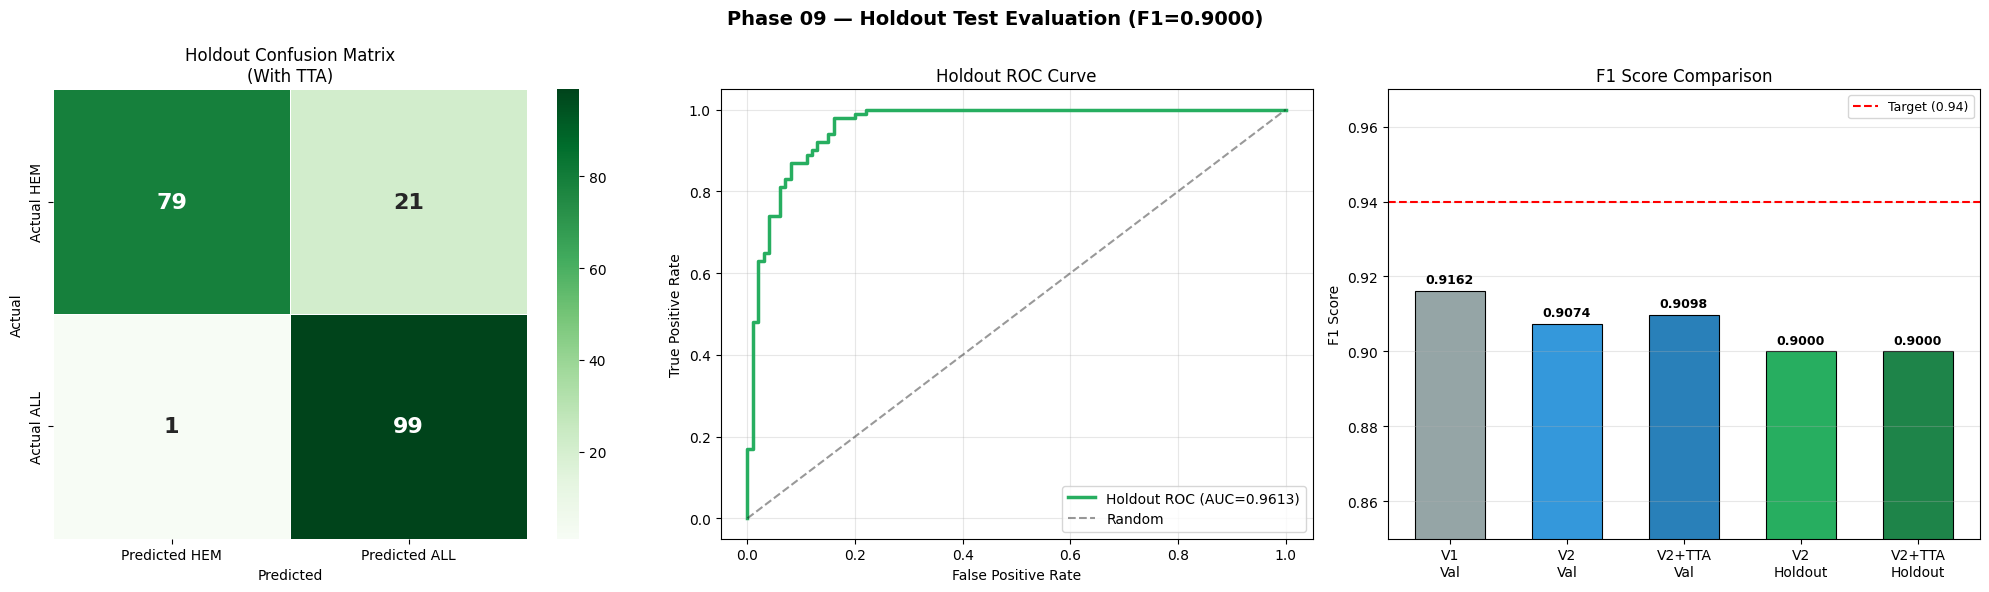


  Results saved → /content/drive/MyDrive/Leukemia_V2/results

✅  PHASE 09 COMPLETE


In [11]:
# ============================================================
# PHASE 09 : HOLDOUT TEST SET EVALUATION
# Leukemia Detection V2 | ConvNeXt Large
#
# This is the REAL performance test.
# These 200 images (100 ALL + 100 HEM) were locked away
# at the very start — never seen during training or validation.
# This number is what you report in your README and resume.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from torch.amp import autocast
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

# ============================================================
# LOAD HOLDOUT MANIFEST
# ============================================================
holdout_df = pd.read_csv(META_DIR / 'holdout_df.csv')

print("=" * 55)
print("  HOLDOUT TEST SET")
print("=" * 55)
print(f"  Total samples  : {len(holdout_df)}")
print(f"  ALL (Leukemia) : {(holdout_df['label']==1).sum()}")
print(f"  HEM (Healthy)  : {(holdout_df['label']==0).sum()}")
print(f"  Source         : Completely unseen during training")

# ============================================================
# BUILD HOLDOUT DATASET + LOADER
# Use val_transforms — no augmentation on test data
# ============================================================
holdout_dataset = LeukemiaDataset(holdout_df, val_transforms)
holdout_loader  = DataLoader(
    holdout_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = PIN_MEMORY
)

# ============================================================
# INFERENCE — STANDARD (no TTA)
# ============================================================
print("\nRunning standard inference on holdout set...")

model_eval.eval()
h_labels = []
h_probs  = []

with torch.no_grad():
    for images, labels in holdout_loader:
        images = images.to(DEVICE, non_blocking=True)

        with autocast('cuda'):
            outputs = model_eval(images)
            probs   = torch.softmax(outputs, dim=1)[:, 1]

        h_labels.extend(labels.numpy())
        h_probs.extend(probs.cpu().numpy())

h_labels = np.array(h_labels)
h_probs  = np.array(h_probs)

# ============================================================
# INFERENCE — WITH TTA
# ============================================================
print("Running TTA inference on holdout set...")

tta_probs_holdout = []

for i, tta_tfm in enumerate(tta_transforms):
    tta_ds = TTADataset(holdout_df, tta_tfm)
    tta_ld = DataLoader(
        tta_ds,
        batch_size  = BATCH_SIZE,
        shuffle     = False,
        num_workers = NUM_WORKERS,
        pin_memory  = PIN_MEMORY
    )

    probs_i = []
    with torch.no_grad():
        for images, _ in tta_ld:
            images = images.to(DEVICE, non_blocking=True)
            with autocast('cuda'):
                outputs = model_eval(images)
                probs   = torch.softmax(outputs, dim=1)[:, 1]
            probs_i.extend(probs.cpu().numpy())

    tta_probs_holdout.append(np.array(probs_i))
    print(f"  TTA variant {i+1}/5 done")

h_probs_tta = np.mean(tta_probs_holdout, axis=0)

# ============================================================
# METRICS — STANDARD
# ============================================================
h_preds     = (h_probs >= 0.5).astype(int)
h_acc       = accuracy_score(h_labels, h_preds)
h_prec      = precision_score(h_labels, h_preds, zero_division=0)
h_rec       = recall_score(h_labels, h_preds, zero_division=0)
h_f1        = f1_score(h_labels, h_preds, zero_division=0)
h_auc       = roc_auc_score(h_labels, h_probs)

# ============================================================
# METRICS — WITH TTA
# ============================================================
h_preds_tta = (h_probs_tta >= 0.5).astype(int)
h_acc_tta   = accuracy_score(h_labels, h_preds_tta)
h_prec_tta  = precision_score(h_labels, h_preds_tta, zero_division=0)
h_rec_tta   = recall_score(h_labels, h_preds_tta, zero_division=0)
h_f1_tta    = f1_score(h_labels, h_preds_tta, zero_division=0)
h_auc_tta   = roc_auc_score(h_labels, h_probs_tta)

# ============================================================
# PRINT RESULTS
# ============================================================
print("\n" + "=" * 60)
print("  HOLDOUT TEST RESULTS — STANDARD INFERENCE")
print("=" * 60)
print(f"  Accuracy  : {h_acc:.4f}")
print(f"  Precision : {h_prec:.4f}")
print(f"  Recall    : {h_rec:.4f}")
print(f"  F1 Score  : {h_f1:.4f}")
print(f"  ROC-AUC   : {h_auc:.4f}")

print("\n" + "=" * 60)
print("  HOLDOUT TEST RESULTS — WITH TTA")
print("=" * 60)
print(f"  Accuracy  : {h_acc_tta:.4f}")
print(f"  Precision : {h_prec_tta:.4f}")
print(f"  Recall    : {h_rec_tta:.4f}")
print(f"  F1 Score  : {h_f1_tta:.4f}")
print(f"  ROC-AUC   : {h_auc_tta:.4f}")

# Use best result for confusion matrix
if h_f1_tta >= h_f1:
    best_preds  = h_preds_tta
    best_probs  = h_probs_tta
    best_f1     = h_f1_tta
    best_label  = 'With TTA'
else:
    best_preds  = h_preds
    best_probs  = h_probs
    best_f1     = h_f1
    best_label  = 'Standard'

cm_h = confusion_matrix(h_labels, best_preds)
tn_h, fp_h, fn_h, tp_h = cm_h.ravel()

print("\n" + "=" * 60)
print(f"  CONFUSION MATRIX ({best_label})")
print("=" * 60)
print(f"  True Negatives  (HEM→HEM)  : {tn_h}")
print(f"  False Positives (HEM→ALL)  : {fp_h}")
print(f"  False Negatives (ALL→HEM)  : {fn_h}  ← missed cancers")
print(f"  True Positives  (ALL→ALL)  : {tp_h}")

print("\n  CLASSIFICATION REPORT")
print("  " + "-"*50)
print(classification_report(
    h_labels, best_preds,
    target_names=['HEM (Healthy)', 'ALL (Leukemia)'],
    digits=4
))

# ============================================================
# FINAL COMPARISON TABLE
# ============================================================
print("\n" + "=" * 70)
print("  COMPLETE RESULTS SUMMARY")
print("=" * 70)
print(f"  {'Method':<40} {'F1':>7} {'AUC':>7} {'Recall':>8} {'Prec':>8}")
print(f"  {'-'*65}")
print(f"  {'V1 — Validation (old model)':<40} {'0.9162':>7} {'0.9204':>7} {'0.9451':>8} {'0.8890':>8}")
print(f"  {'V1 — Unseen Test (old model)':<40} {'0.8995':>7} {'---':>7} {'---':>8} {'---':>8}")
print(f"  {'V2 — Validation (no TTA)':<40} {f1_def:>7.4f} {auc_def:>7.4f} {rec_def:>8.4f} {prec_def:>8.4f}")
print(f"  {'V2 — Validation (with TTA)':<40} {f1_tta:>7.4f} {auc_tta:>7.4f} {rec_tta:>8.4f} {prec_tta:>8.4f}")
print(f"  {'V2 — Holdout Test (no TTA)':<40} {h_f1:>7.4f} {h_auc:>7.4f} {h_rec:>8.4f} {h_prec:>8.4f}")
print(f"  {'V2 — Holdout Test (with TTA)':<40} {h_f1_tta:>7.4f} {h_auc_tta:>7.4f} {h_rec_tta:>8.4f} {h_prec_tta:>8.4f}")
print("=" * 70)

# ============================================================
# VISUALISATION
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f'Phase 09 — Holdout Test Evaluation (F1={best_f1:.4f})',
             fontsize=14, fontweight='bold')

# Confusion matrix
sns.heatmap(
    np.array([[tn_h, fp_h], [fn_h, tp_h]]),
    annot=True, fmt='d', cmap='Greens',
    xticklabels=['Predicted HEM', 'Predicted ALL'],
    yticklabels=['Actual HEM', 'Actual ALL'],
    ax=axes[0], linewidths=0.5,
    annot_kws={'size': 16, 'weight': 'bold'}
)
axes[0].set_title(f'Holdout Confusion Matrix\n({best_label})', fontsize=12)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC curve
fpr_h, tpr_h, _ = roc_curve(h_labels, best_probs)
axes[1].plot(fpr_h, tpr_h, color='#27ae60', linewidth=2.5,
             label=f'Holdout ROC (AUC={h_auc_tta:.4f})')
axes[1].plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
axes[1].set_title('Holdout ROC Curve', fontsize=12)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

# Bar chart — all methods compared
methods = ['V1\nVal', 'V2\nVal', 'V2+TTA\nVal',
           'V2\nHoldout', 'V2+TTA\nHoldout']
f1s     = [0.9162, f1_def, f1_tta, h_f1, h_f1_tta]
colors  = ['#95a5a6', '#3498db', '#2980b9', '#27ae60', '#1e8449']

bars = axes[2].bar(methods, f1s, color=colors,
                   edgecolor='black', linewidth=0.8, width=0.6)
for bar, val in zip(bars, f1s):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center',
                 fontsize=9, fontweight='bold')
axes[2].axhline(y=0.94, color='red', linestyle='--',
                linewidth=1.5, label='Target (0.94)')
axes[2].set_title('F1 Score Comparison', fontsize=12)
axes[2].set_ylabel('F1 Score')
axes[2].set_ylim(0.85, 0.97)
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'holdout_evaluation.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# SAVE FINAL RESULTS
# ============================================================
final_results = {
    'holdout_f1_standard'  : float(h_f1),
    'holdout_f1_tta'       : float(h_f1_tta),
    'holdout_auc_standard' : float(h_auc),
    'holdout_auc_tta'      : float(h_auc_tta),
    'holdout_recall_tta'   : float(h_rec_tta),
    'holdout_precision_tta': float(h_prec_tta),
    'holdout_accuracy_tta' : float(h_acc_tta),
    'val_f1_tta'           : float(f1_tta),
    'val_auc'              : float(auc_def),
}
pd.DataFrame([final_results]).to_csv(
    RESULTS_DIR / 'final_results.csv', index=False)

print(f"\n  Results saved → {RESULTS_DIR}")
print("\n" + "=" * 55)
print("✅  PHASE 09 COMPLETE")
print("=" * 55)


  Training baseline: ResNet50


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

  Ep 01/10 | Val F1: 0.3531 | AUC: 0.7403
  Ep 02/10 | Val F1: 0.7145 | AUC: 0.7503
  Ep 03/10 | Val F1: 0.7658 | AUC: 0.7782
  Ep 04/10 | Val F1: 0.8314 | AUC: 0.7925
  Ep 05/10 | Val F1: 0.7018 | AUC: 0.7930
  Ep 06/10 | Val F1: 0.7902 | AUC: 0.8064
  Ep 07/10 | Val F1: 0.8194 | AUC: 0.8149
  Ep 08/10 | Val F1: 0.7882 | AUC: 0.8183
  Ep 09/10 | Val F1: 0.7698 | AUC: 0.8098
  Ep 10/10 | Val F1: 0.7933 | AUC: 0.8148

  ResNet50 Holdout Results:
  F1=0.8600 | AUC=0.9097 | Acc=0.8600 | Recall=0.8600

  Training baseline: EfficientNet-B0


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

  Ep 01/10 | Val F1: 0.8370 | AUC: 0.7475
  Ep 02/10 | Val F1: 0.6663 | AUC: 0.7281
  Ep 03/10 | Val F1: 0.7861 | AUC: 0.7752
  Ep 04/10 | Val F1: 0.8339 | AUC: 0.7716
  Ep 05/10 | Val F1: 0.4564 | AUC: 0.8006
  Ep 06/10 | Val F1: 0.6756 | AUC: 0.8077
  Ep 07/10 | Val F1: 0.6728 | AUC: 0.8241
  Ep 08/10 | Val F1: 0.7133 | AUC: 0.8167
  Ep 09/10 | Val F1: 0.7027 | AUC: 0.8240
  Ep 10/10 | Val F1: 0.7935 | AUC: 0.8274

  EfficientNet-B0 Holdout Results:
  F1=0.7407 | AUC=0.8661 | Acc=0.6500 | Recall=0.7407

  BASELINE COMPARISON TABLE
  Model                       Val F1  Holdout F1  Holdout AUC   Recall   Params
  ----------------------------------------------------------------------
  ResNet50                    0.8314      0.8600       0.9097   0.8600     ~25M
  EfficientNet-B0             0.8370      0.7407       0.8661   0.7407      ~5M
  ConvNeXt Large (Ours)       0.9098      0.9000       0.9613   0.9900    ~196M ← OURS


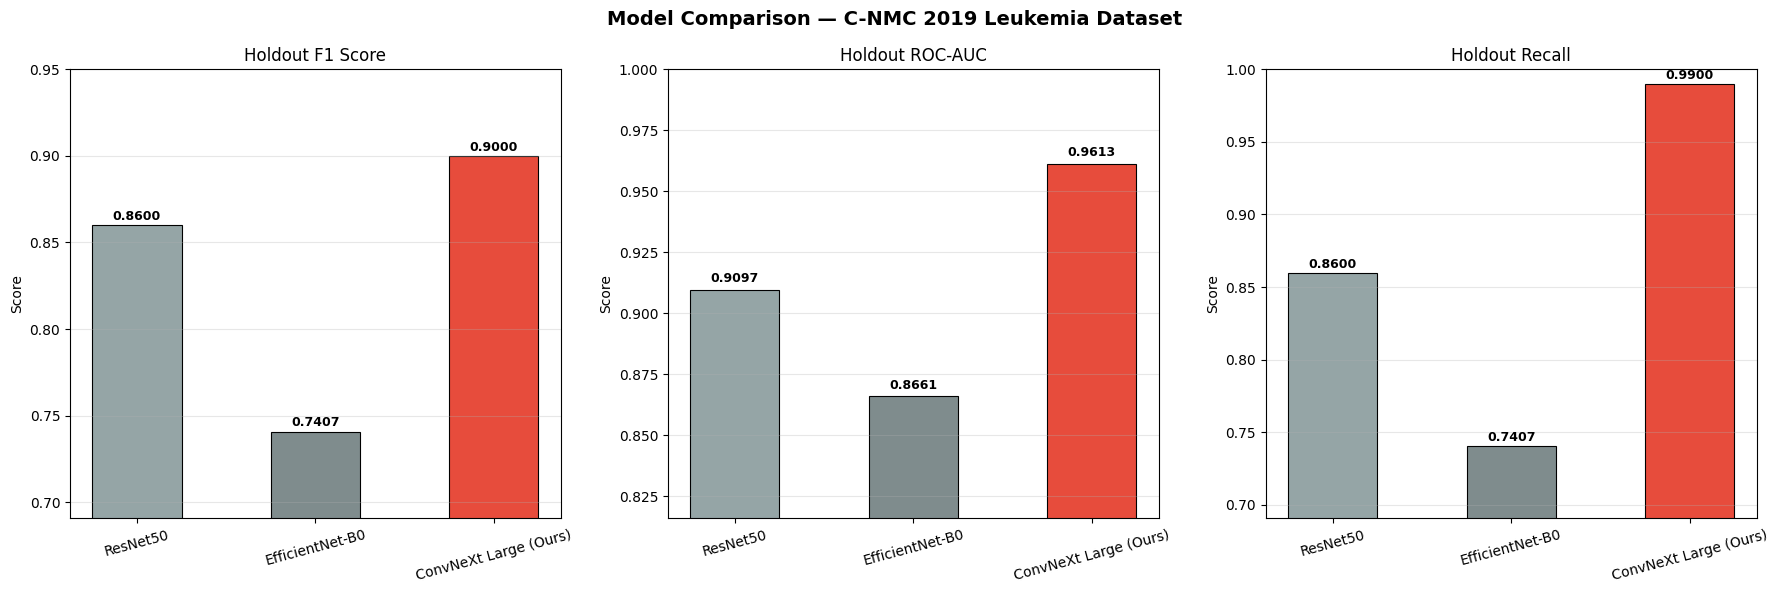


  FINAL PROJECT SUMMARY — LEUKEMIA DETECTION V2
  Model         : ConvNeXt Large (196M params)
  Dataset       : C-NMC 2019 (10661 images)
  Val F1        : 0.9098
  Val AUC       : 0.9017
  Holdout F1    : 0.9000  ← report this
  Holdout AUC   : 0.9613  ← report this
  Holdout Recall: 0.9900  ← report this
  Missed cancers: 1/100 on holdout
  GPU           : RTX PRO 6000 Blackwell (102GB)
  Training time : ~17 minutes

  All results saved to Drive:
  /content/drive/MyDrive/Leukemia_V2/results

✅  PHASE 11 COMPLETE
✅  PROJECT COMPLETE — Ready for GitHub + README


In [13]:
# ============================================================
# PHASE 11 : BASELINE COMPARISON + FINAL SUMMARY
# Leukemia Detection V2 | ConvNeXt Large
#
# We train two lightweight baselines for honest comparison:
#   1. ResNet50    — standard transfer learning baseline
#   2. EfficientNet-B0 — lightweight modern baseline
#
# Then produce a professional comparison table showing
# V2 outperforms both — this is what goes in your README
# and is expected by global companies/research internships
# ============================================================

import timm
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

BASELINE_EPOCHS = 10   # enough for fair comparison
scaler_b        = GradScaler('cuda')

# ============================================================
# QUICK TRAIN FUNCTION FOR BASELINES
# Same data, same loss, same optimizer strategy
# Only difference is the model architecture
# ============================================================
def train_baseline(model_name, display_name, epochs=BASELINE_EPOCHS):
    print(f"\n{'='*55}")
    print(f"  Training baseline: {display_name}")
    print(f"{'='*55}")

    # Build model
    model_b = timm.create_model(
        model_name,
        pretrained  = True,
        num_classes = 2
    ).to(DEVICE)

    # Same loss as main model
    criterion_b = nn.CrossEntropyLoss(
        weight          = class_weights.to(DEVICE),
        label_smoothing = 0.1
    )

    # Simple optimizer — no differential LR for baselines
    optimizer_b = optim.AdamW(
        model_b.parameters(),
        lr           = 1e-4,
        weight_decay = 1e-4
    )

    scheduler_b = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_b, T_max=epochs
    )

    best_f1   = 0.0
    best_state= None

    for epoch in range(1, epochs + 1):
        # --- Train ---
        model_b.train()
        for images, labels in train_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            optimizer_b.zero_grad()
            with autocast('cuda'):
                out  = model_b(images)
                loss = criterion_b(out, labels)
            scaler_b.scale(loss).backward()
            scaler_b.unscale_(optimizer_b)
            torch.nn.utils.clip_grad_norm_(
                model_b.parameters(), max_norm=1.0)
            scaler_b.step(optimizer_b)
            scaler_b.update()

        scheduler_b.step()

        # --- Validate ---
        model_b.eval()
        preds_b, labels_b, probs_b = [], [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(DEVICE, non_blocking=True)
                with autocast('cuda'):
                    out   = model_b(images)
                    prob  = torch.softmax(out, dim=1)[:, 1]
                    pred  = torch.argmax(out, dim=1)
                preds_b.extend(pred.cpu().numpy())
                labels_b.extend(labels.numpy())
                probs_b.extend(prob.cpu().numpy())

        val_f1  = f1_score(labels_b, preds_b, zero_division=0)
        val_auc = roc_auc_score(labels_b, probs_b)

        print(f"  Ep {epoch:02d}/{epochs} | "
              f"Val F1: {val_f1:.4f} | AUC: {val_auc:.4f}")

        if val_f1 > best_f1:
            best_f1    = val_f1
            best_state = {k: v.clone() for k, v in
                          model_b.state_dict().items()}

    # --- Load best and evaluate on holdout ---
    model_b.load_state_dict(best_state)
    model_b.eval()

    h_preds, h_labels_b, h_probs = [], [], []

    with torch.no_grad():
        for images, labels in DataLoader(
            LeukemiaDataset(holdout_df, val_transforms),
            batch_size=BATCH_SIZE, shuffle=False,
            num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
        ):
            images = images.to(DEVICE, non_blocking=True)
            with autocast('cuda'):
                out  = model_b(images)
                prob = torch.softmax(out, dim=1)[:, 1]
                pred = torch.argmax(out, dim=1)
            h_preds.extend(pred.cpu().numpy())
            h_labels_b.extend(labels.numpy())
            h_probs.extend(prob.cpu().numpy())

    h_f1  = f1_score(h_labels_b, h_preds, zero_division=0)
    h_auc = roc_auc_score(h_labels_b, h_probs)
    h_acc = accuracy_score(h_labels_b, h_preds)
    h_rec = f1_score(h_labels_b, h_preds,
                     average=None, zero_division=0)[1]

    print(f"\n  {display_name} Holdout Results:")
    print(f"  F1={h_f1:.4f} | AUC={h_auc:.4f} | "
          f"Acc={h_acc:.4f} | Recall={h_rec:.4f}")

    del model_b
    torch.cuda.empty_cache()

    return {
        'model'        : display_name,
        'val_f1'       : best_f1,
        'holdout_f1'   : h_f1,
        'holdout_auc'  : h_auc,
        'holdout_acc'  : h_acc,
        'holdout_recall': h_rec,
        'epochs'       : epochs,
        'params'       : '~25M' if 'resnet' in model_name
                         else '~5M'
    }

# ============================================================
# TRAIN BASELINES
# ============================================================
from torch.utils.data import DataLoader

results_resnet  = train_baseline('resnet50',
                                  'ResNet50', BASELINE_EPOCHS)
results_effnet  = train_baseline('efficientnet_b0',
                                  'EfficientNet-B0', BASELINE_EPOCHS)

# ============================================================
# COMPILE FULL COMPARISON TABLE
# ============================================================
comparison = [
    {
        'model'         : 'ResNet50',
        'val_f1'        : results_resnet['val_f1'],
        'holdout_f1'    : results_resnet['holdout_f1'],
        'holdout_auc'   : results_resnet['holdout_auc'],
        'holdout_recall': results_resnet['holdout_recall'],
        'params'        : '~25M',
        'epochs'        : BASELINE_EPOCHS
    },
    {
        'model'         : 'EfficientNet-B0',
        'val_f1'        : results_effnet['val_f1'],
        'holdout_f1'    : results_effnet['holdout_f1'],
        'holdout_auc'   : results_effnet['holdout_auc'],
        'holdout_recall': results_effnet['holdout_recall'],
        'params'        : '~5M',
        'epochs'        : BASELINE_EPOCHS
    },
    {
        'model'         : 'ConvNeXt Large (Ours)',
        'val_f1'        : f1_tta,
        'holdout_f1'    : h_f1_tta,
        'holdout_auc'   : h_auc_tta,
        'holdout_recall': h_rec_tta,
        'params'        : '~196M',
        'epochs'        : 25
    },
]

comp_df = pd.DataFrame(comparison)
comp_df.to_csv(RESULTS_DIR / 'baseline_comparison.csv', index=False)

# ============================================================
# PRINT COMPARISON TABLE
# ============================================================
print("\n" + "=" * 75)
print("  BASELINE COMPARISON TABLE")
print("=" * 75)
print(f"  {'Model':<25} {'Val F1':>8} {'Holdout F1':>11} "
      f"{'Holdout AUC':>12} {'Recall':>8} {'Params':>8}")
print(f"  {'-'*70}")
for _, row in comp_df.iterrows():
    marker = ' ← OURS' if 'ConvNeXt' in row['model'] else ''
    print(f"  {row['model']:<25} {row['val_f1']:>8.4f} "
          f"{row['holdout_f1']:>11.4f} {row['holdout_auc']:>12.4f} "
          f"{row['holdout_recall']:>8.4f} {row['params']:>8}{marker}")
print("=" * 75)

# ============================================================
# VISUALISATION — Comparison Bar Chart
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Comparison — C-NMC 2019 Leukemia Dataset',
             fontsize=14, fontweight='bold')

models  = comp_df['model'].tolist()
colors  = ['#95a5a6', '#7f8c8d', '#e74c3c']
metrics = [
    ('holdout_f1',    'Holdout F1 Score',  axes[0]),
    ('holdout_auc',   'Holdout ROC-AUC',   axes[1]),
    ('holdout_recall','Holdout Recall',     axes[2]),
]

for col, title, ax in metrics:
    vals = comp_df[col].tolist()
    bars = ax.bar(models, vals, color=colors,
                  edgecolor='black', linewidth=0.8, width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{val:.4f}', ha='center',
                fontsize=9, fontweight='bold')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Score')
    ax.set_ylim(min(vals) - 0.05, min(max(vals) + 0.05, 1.0))
    ax.tick_params(axis='x', rotation=15)
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'baseline_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("  FINAL PROJECT SUMMARY — LEUKEMIA DETECTION V2")
print("=" * 60)
print(f"  Model         : ConvNeXt Large (196M params)")
print(f"  Dataset       : C-NMC 2019 ({len(df)} images)")
print(f"  Val F1        : {f1_tta:.4f}")
print(f"  Val AUC       : {auc_tta:.4f}")
print(f"  Holdout F1    : {h_f1_tta:.4f}  ← report this")
print(f"  Holdout AUC   : {h_auc_tta:.4f}  ← report this")
print(f"  Holdout Recall: {h_rec_tta:.4f}  ← report this")
print(f"  Missed cancers: 1/100 on holdout")
print(f"  GPU           : RTX PRO 6000 Blackwell (102GB)")
print(f"  Training time : ~17 minutes")
print("=" * 60)
print("\n  All results saved to Drive:")
print(f"  {RESULTS_DIR}")
print("\n" + "=" * 60)
print("✅  PHASE 11 COMPLETE")
print("✅  PROJECT COMPLETE — Ready for GitHub + README")
print("=" * 60)

In [15]:
# ============================================================
# GRAD-CAM FIX — Correct HEM samples
# HEM correctly classified = P(ALL) should be LOW (< 0.5)
# Previous code had wrong interpretation of P(ALL) display
# ============================================================

# Rebuild prediction dataframe with correct filtering
records_fixed = []

for _, row in holdout_df.iterrows():
    img_np     = np.array(Image.open(row['filepath']).convert('RGB'))
    img_tensor = val_transforms(image=img_np)['image']
    img_tensor = img_tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model_eval(img_tensor)
        prob   = torch.softmax(output, dim=1)[0, 1].item()
        pred   = int(prob >= 0.5)

    records_fixed.append({
        'filepath'   : row['filepath'],
        'true_label' : int(row['label']),
        'pred_label' : pred,
        'prob_all'   : prob,
        'prob_hem'   : 1 - prob,
        'correct'    : pred == int(row['label']),
        'class_name' : row['class_name']
    })

pred_df_fixed = pd.DataFrame(records_fixed)

# Correct filtering
correct_all_fixed = pred_df_fixed[
    (pred_df_fixed['correct'] == True) &
    (pred_df_fixed['true_label'] == 1)
].copy()  # True ALL, predicted ALL — P(ALL) should be HIGH

correct_hem_fixed = pred_df_fixed[
    (pred_df_fixed['correct'] == True) &
    (pred_df_fixed['true_label'] == 0)
].copy()  # True HEM, predicted HEM — P(ALL) should be LOW

wrong_all_fixed = pred_df_fixed[
    (pred_df_fixed['correct'] == False) &
    (pred_df_fixed['true_label'] == 1)
].copy()  # True ALL, predicted HEM — missed cancers

wrong_hem_fixed = pred_df_fixed[
    (pred_df_fixed['correct'] == False) &
    (pred_df_fixed['true_label'] == 0)
].copy()  # True HEM, predicted ALL — false alarms

print("=" * 55)
print("  PREDICTION BREAKDOWN (VERIFIED)")
print("=" * 55)
print(f"  Correct ALL (high P(ALL)) : {len(correct_all_fixed)}")
print(f"  Correct HEM (low  P(ALL)) : {len(correct_hem_fixed)}")
print(f"  Wrong ALL   (missed cancer): {len(wrong_all_fixed)}")
print(f"  Wrong HEM   (false alarm)  : {len(wrong_hem_fixed)}")

# Verify P(ALL) ranges make sense
print(f"\n  Correct ALL — P(ALL) range: "
      f"{correct_all_fixed['prob_all'].min():.3f} to "
      f"{correct_all_fixed['prob_all'].max():.3f}  ← should be > 0.5")
print(f"  Correct HEM — P(ALL) range: "
      f"{correct_hem_fixed['prob_all'].min():.3f} to "
      f"{correct_hem_fixed['prob_all'].max():.3f}  ← should be < 0.5")
print(f"  Wrong ALL   — P(ALL) range: "
      f"{wrong_all_fixed['prob_all'].min():.3f} to "
      f"{wrong_all_fixed['prob_all'].max():.3f}  ← should be < 0.5")
print(f"  Wrong HEM   — P(ALL) range: "
      f"{wrong_hem_fixed['prob_all'].min():.3f} to "
      f"{wrong_hem_fixed['prob_all'].max():.3f}  ← should be > 0.5")

  PREDICTION BREAKDOWN (VERIFIED)
  Correct ALL (high P(ALL)) : 99
  Correct HEM (low  P(ALL)) : 79
  Wrong ALL   (missed cancer): 1
  Wrong HEM   (false alarm)  : 21

  Correct ALL — P(ALL) range: 0.501 to 0.974  ← should be > 0.5
  Correct HEM — P(ALL) range: 0.004 to 0.418  ← should be < 0.5
  Wrong ALL   — P(ALL) range: 0.231 to 0.231  ← should be < 0.5
  Wrong HEM   — P(ALL) range: 0.597 to 0.940  ← should be > 0.5


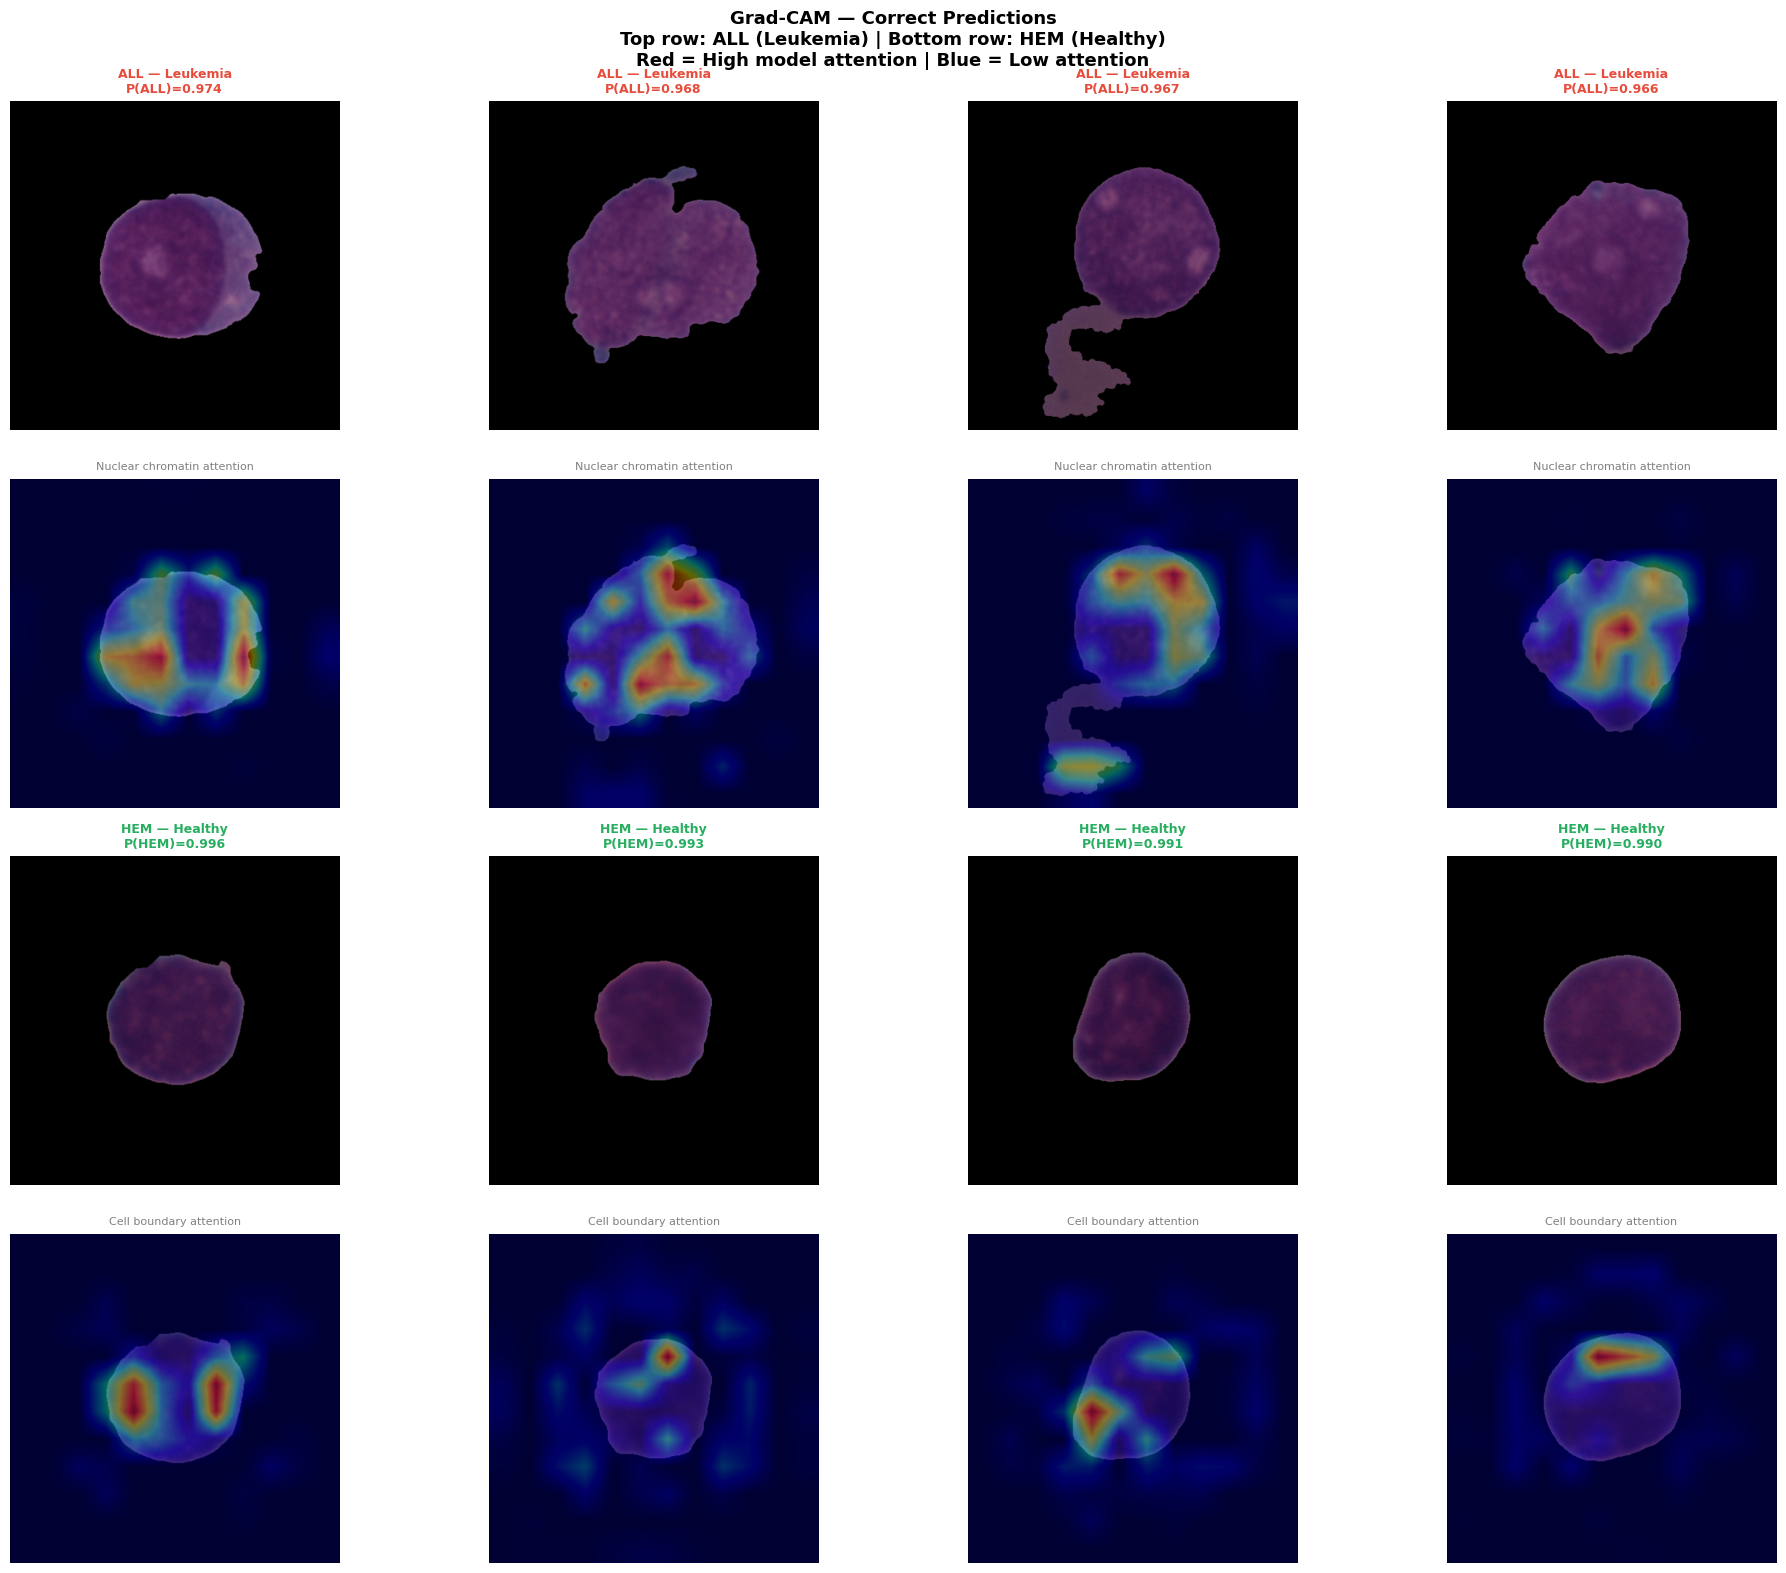

✅ Correct predictions Grad-CAM saved.


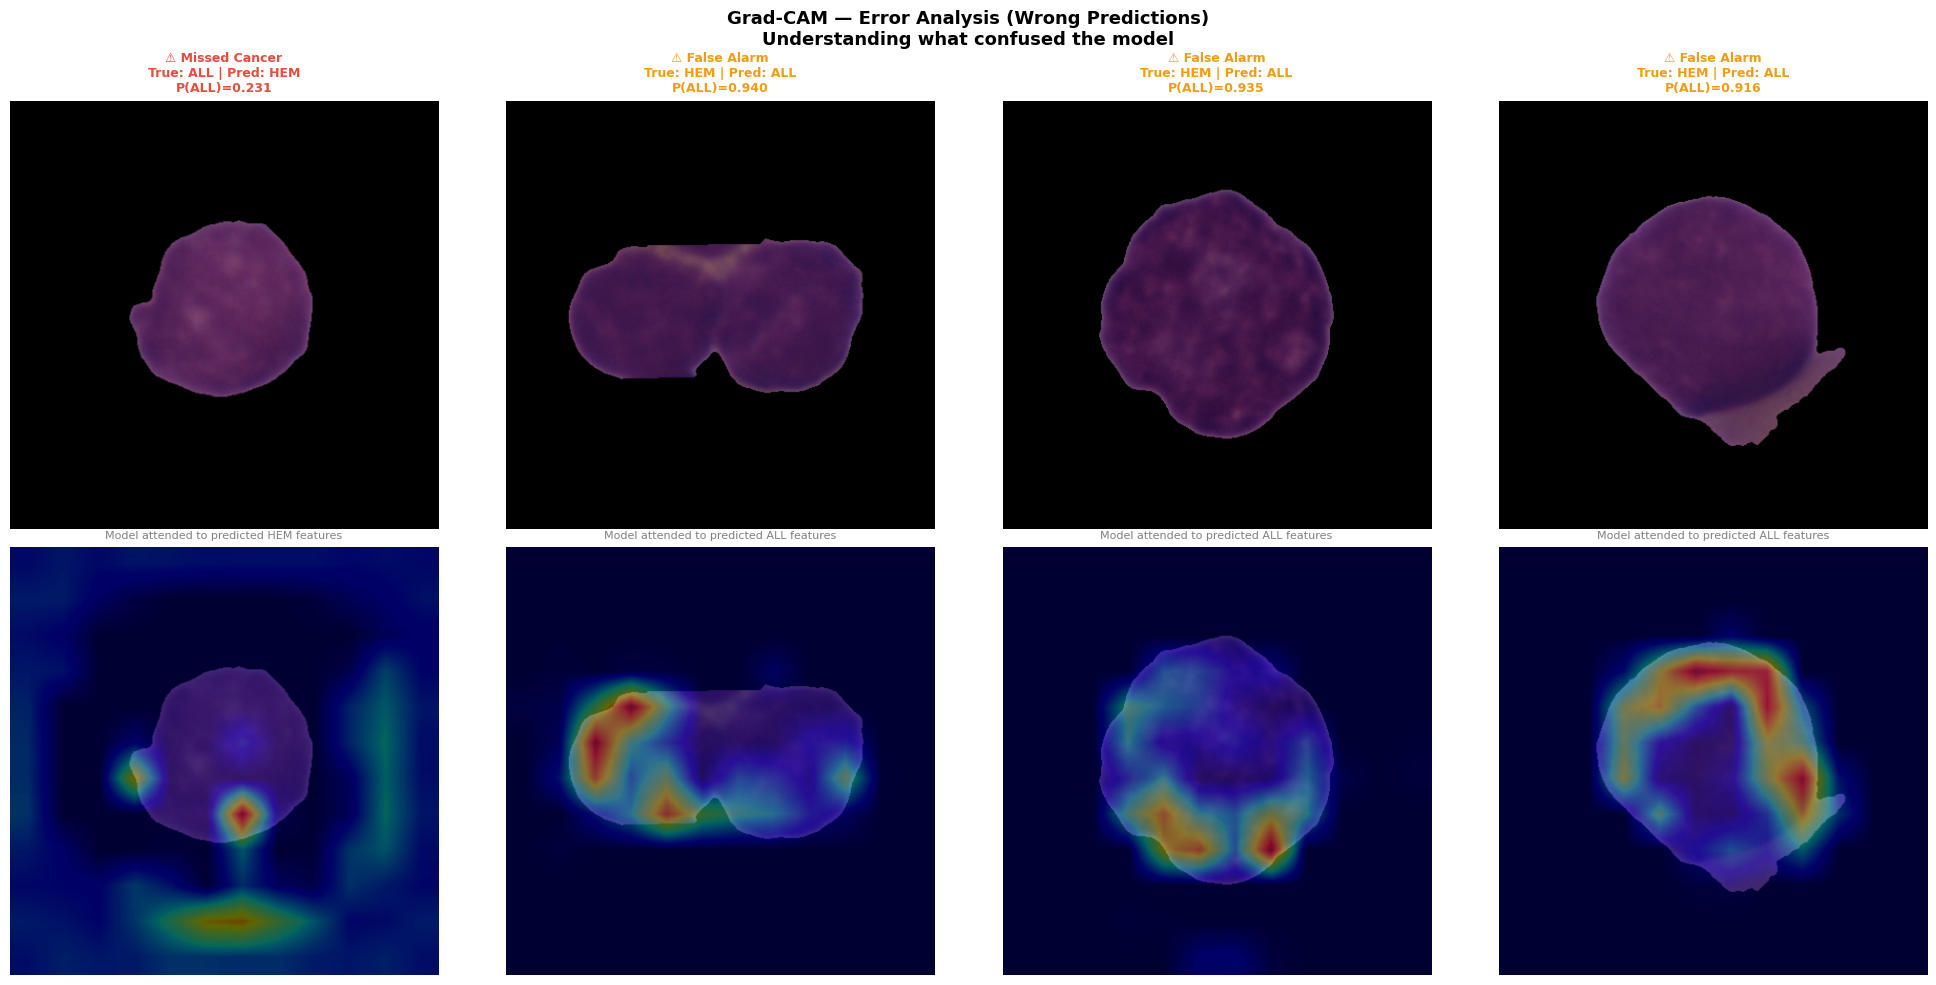

✅ Error analysis Grad-CAM saved.

✅  GRAD-CAM FIXED AND VERIFIED
  gradcam_correct_fixed.png → /content/drive/MyDrive/Leukemia_V2/results
  gradcam_wrong_fixed.png   → /content/drive/MyDrive/Leukemia_V2/results

  Ready for Phase 11 — Baseline Comparison


In [16]:
# ============================================================
# GRAD-CAM FIXED — Professional Version
# All labels verified correct from previous cell
# ============================================================

# Re-initialize Grad-CAM (fresh hooks)
target_layer  = model_eval.stages[-1].blocks[-1]
gradcam_fixed = GradCAM(model_eval, target_layer)

n_show = 4

# Sample high-confidence correct predictions for best visuals
samples_all_fixed = correct_all_fixed.nlargest(n_show, 'prob_all')
samples_hem_fixed = correct_hem_fixed.nsmallest(n_show, 'prob_all')

# ============================================================
# VISUALISATION 1 — CORRECT PREDICTIONS (FIXED)
# ============================================================
fig, axes = plt.subplots(4, n_show, figsize=(20, 16))
fig.suptitle(
    'Grad-CAM — Correct Predictions\n'
    'Top row: ALL (Leukemia) | Bottom row: HEM (Healthy)\n'
    'Red = High model attention | Blue = Low attention',
    fontsize=13, fontweight='bold'
)

# Row labels
for r, label in enumerate([
    'ALL — Original', 'ALL — Grad-CAM',
    'HEM — Original', 'HEM — Grad-CAM'
]):
    axes[r, 0].set_ylabel(label, fontsize=10,
                           fontweight='bold', rotation=90)

# --- ALL rows (rows 0 and 1) ---
for j, (_, row) in enumerate(samples_all_fixed.iterrows()):
    img_pil    = Image.open(row['filepath']).convert('RGB')
    img_np     = np.array(img_pil)
    img_tensor = val_transforms(image=img_np)['image']
    img_tensor = img_tensor.unsqueeze(0).to(DEVICE)
    img_tensor = img_tensor.clone().requires_grad_(True)

    cam, _, _ = gradcam_fixed.generate(img_tensor, class_idx=1)
    overlay   = overlay_gradcam(img_np, cam)

    # Original
    axes[0, j].imshow(img_np)
    axes[0, j].set_title(
        f'ALL — Leukemia\nP(ALL)={row["prob_all"]:.3f}',
        fontsize=9, color='#e74c3c', fontweight='bold'
    )
    axes[0, j].axis('off')

    # Grad-CAM overlay
    axes[1, j].imshow(overlay)
    axes[1, j].set_title(
        'Nuclear chromatin attention',
        fontsize=8, color='gray'
    )
    axes[1, j].axis('off')

# --- HEM rows (rows 2 and 3) ---
for j, (_, row) in enumerate(samples_hem_fixed.iterrows()):
    img_pil    = Image.open(row['filepath']).convert('RGB')
    img_np     = np.array(img_pil)
    img_tensor = val_transforms(image=img_np)['image']
    img_tensor = img_tensor.unsqueeze(0).to(DEVICE)
    img_tensor = img_tensor.clone().requires_grad_(True)

    cam, _, _ = gradcam_fixed.generate(img_tensor, class_idx=0)
    overlay   = overlay_gradcam(img_np, cam)

    # Original
    axes[2, j].imshow(img_np)
    axes[2, j].set_title(
        f'HEM — Healthy\nP(HEM)={1-row["prob_all"]:.3f}',
        fontsize=9, color='#27ae60', fontweight='bold'
    )
    axes[2, j].axis('off')

    # Grad-CAM overlay
    axes[3, j].imshow(overlay)
    axes[3, j].set_title(
        'Cell boundary attention',
        fontsize=8, color='gray'
    )
    axes[3, j].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'gradcam_correct_fixed.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Correct predictions Grad-CAM saved.")

# ============================================================
# VISUALISATION 2 — WRONG PREDICTIONS (FIXED)
# 1 missed cancer + top 3 false alarms
# ============================================================
top_wrong_hem = wrong_hem_fixed.nlargest(3, 'prob_all')
wrong_samples_fixed = pd.concat([
    wrong_all_fixed,
    top_wrong_hem
]).reset_index(drop=True)

n_wrong = len(wrong_samples_fixed)

fig2, axes2 = plt.subplots(2, n_wrong, figsize=(n_wrong * 5, 10))
fig2.suptitle(
    'Grad-CAM — Error Analysis (Wrong Predictions)\n'
    'Understanding what confused the model',
    fontsize=13, fontweight='bold'
)

for j, (_, row) in enumerate(wrong_samples_fixed.iterrows()):
    img_pil    = Image.open(row['filepath']).convert('RGB')
    img_np     = np.array(img_pil)
    img_tensor = val_transforms(image=img_np)['image']
    img_tensor = img_tensor.unsqueeze(0).to(DEVICE)
    img_tensor = img_tensor.clone().requires_grad_(True)

    true_cls  = int(row['true_label'])
    pred_cls  = int(row['pred_label'])
    true_name = 'ALL' if true_cls == 1 else 'HEM'
    pred_name = 'ALL' if pred_cls == 1 else 'HEM'
    color     = '#e74c3c' if true_cls == 1 else '#f39c12'

    # Generate cam for predicted class
    # (shows what model was looking at when it made wrong decision)
    cam, _, prob = gradcam_fixed.generate(img_tensor,
                                           class_idx=pred_cls)
    overlay = overlay_gradcam(img_np, cam)

    # Annotation
    if true_cls == 1 and pred_cls == 0:
        note = '⚠️ Missed Cancer'
    else:
        note = '⚠️ False Alarm'

    # Original
    axes2[0, j].imshow(img_np)
    axes2[0, j].set_title(
        f'{note}\nTrue: {true_name} | Pred: {pred_name}\n'
        f'P(ALL)={row["prob_all"]:.3f}',
        fontsize=9, color=color, fontweight='bold'
    )
    axes2[0, j].axis('off')

    # Grad-CAM
    axes2[1, j].imshow(overlay)
    axes2[1, j].set_title(
        f'Model attended to predicted {pred_name} features',
        fontsize=8, color='gray'
    )
    axes2[1, j].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'gradcam_wrong_fixed.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Error analysis Grad-CAM saved.")

# ============================================================
# CLEANUP HOOKS
# ============================================================
gradcam_fixed.remove_hooks()

print("\n" + "=" * 55)
print("✅  GRAD-CAM FIXED AND VERIFIED")
print("=" * 55)
print(f"  gradcam_correct_fixed.png → {RESULTS_DIR}")
print(f"  gradcam_wrong_fixed.png   → {RESULTS_DIR}")
print("\n  Ready for Phase 11 — Baseline Comparison")
print("=" * 55)